In [1]:
from InSitu14CO import Propagator
import numpy as np
import matplotlib.pyplot as plt
import crflux.models as pm
import matplotlib.ticker as ticker
import matplotlib as mpl
import Functions_14CO as F

from tqdm import tqdm

import pandas as pd

import scipy

from scipy import stats

from scipy.io import loadmat
from scipy.interpolate import interp1d

import dynesty

In [2]:
# setup pyplot formatting

axes_style = { 'grid'      : 'True',
               'labelsize' : '14',
               'labelpad'  : '8.0'
             }
grid_style = { 'alpha'     : '0.75',
               'linestyle' : ':' }
font_style = { 'size'      : '14' }

mpl.rc('font', **font_style)
mpl.rc('axes', **axes_style)
mpl.rc('grid', **grid_style)

## Dome C

In [3]:
# Create an instance of the Propagator Class

months = [
    'January',
    #'February',
    #'March',
    #'April',
    #'May',
    #'June',
    'July',
    #'August',
    #'September',
    #'October',
    #'November',
    #'December',
]

Prop_DC = Propagator()
density_models_DC = [('MSIS00', ('SouthPole', m)) for m in months]

## Taylor Glacier

In [4]:
# sets the conditions for the study at Taylor Glacier by Dyonisius et al. (https://tc.copernicus.org/articles/17/843/2023/)
rho_ice = 0.92
h_bins = np.arange(0, 1001, 1)
Prop_TG = Propagator(pressure=9.248658001389917e+04, # (Pa) pressure used in Taylor Glacier analysis "from LSD ERA reanalysis"
                  elev=526, # (m) elevation listed in Figure 1 caption of Taylor Glacier study (need to confirm)
                  z_grid=h_bins/rho_ice,
                  h_grid=h_bins,
                  rho_ice=rho_ice,
                  z_close=0,
                 ) # (g/cm^3) density used in Taylor Glacier analysis
density_models_TG = [('MSIS00', ('SouthPole', m)) for m in months]

TG_data = loadmat('matlab/MC_14CO_mod/TG_data_14CO.mat')
CO_exp_TG_data = TG_data['CO_molec'][3:,0]
CO_err_TG_data = TG_data['CO_molec_err'][3:,0]/2.
z_samp_TG = TG_data['sample_depth_CO'][3:,0]

## Setup Time Bins

In [5]:
# Dome C Time Bins
dt_DC = Prop_DC.dt_int[0]
t_bins_DC = Prop_DC.t_int_bins-Prop_DC.t_int_bins[-1]
t_DC = Prop_DC.t_int-Prop_DC.t_int_bins[-1]
Period_DC = t_bins_DC[-1]-t_bins_DC[0]

# Taylor Glacier Time Bins
dt_TG_short = 1
dt_TG_long = 100
Period_TG_short = Period_DC
Period_TG = 50000

t_bins_TG_short = -np.flip(np.arange(0, Period_TG_short+dt_TG_short, dt_TG_short)) # time integration steps
t_TG_short = (t_bins_TG_short[:-1]+t_bins_TG_short[1:])/2
t_bins_TG_long = -np.flip(np.arange(-t_bins_TG_short[0], Period_TG+dt_TG_long, dt_TG_long))
t_TG_long = (t_bins_TG_long[:-1]+t_bins_TG_long[1:])/2

t_bins_TG = np.concatenate((t_bins_TG_long[:-1], t_bins_TG_short))
t_TG = (t_bins_TG[:-1]+t_bins_TG[1:])/2
dt_TG = np.diff(t_bins_TG)

# Full Model Time Bins
Period = Period_TG
t_bins = t_bins_TG
t = t_TG
dt = dt_TG

t_scale = t/Period_DC # time scaled from -1 to 0, with 0=present

f_interp_to_DC = ((t_bins[1:].reshape((-1,1))-t_bins_DC[:-1].reshape((1,-1))).clip(0,dt_DC) - (t_bins[:-1].reshape((-1,1))-t_bins_DC[:-1].reshape((1,-1))).clip(0,dt_DC))/dt_DC
f_interp_to_TG = ((t_bins[1:].reshape((-1,1))-t_bins_TG[:-1].reshape((1,-1))).clip(0,dt_TG) - (t_bins[:-1].reshape((-1,1))-t_bins_TG[:-1].reshape((1,-1))).clip(0,dt_TG))/dt_TG

## Bin Plots

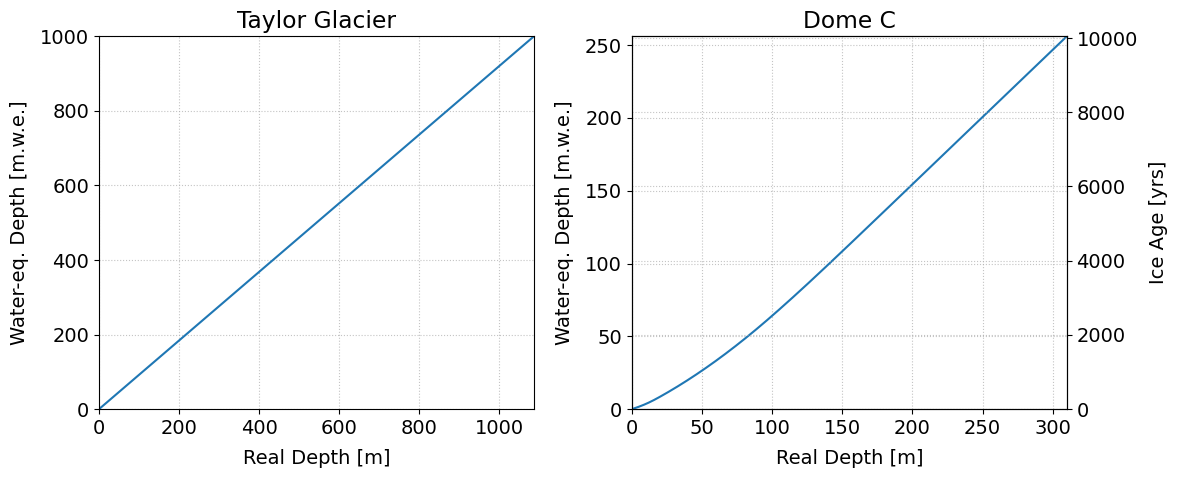

In [6]:
fig, axes = plt.subplots(1,2, figsize=(12,5), tight_layout=True)

# Plot depth, mass depth, and time
axes[0].plot(Prop_TG.z_grid, Prop_TG.h_grid)
axes[0].set(
    xlim=(Prop_TG.z_grid[0], Prop_TG.z_grid[-1]),
    xlabel='Real Depth [m]',
    ylim=(Prop_TG.h_grid[0], Prop_TG.h_grid[-1]),
    ylabel='Water-eq. Depth [m.w.e.]',
    title='Taylor Glacier',
)
#axes[0].grid(which = 'minor', alpha = 0.3)
#axes[0].set_xticks(Prop_TG.z_grid, labels='', minor=True)
#axes[0].legend(loc='lower right', fontsize=10)

# Plot depth, mass depth, and time
axes[1].plot(Prop_DC.z_grid, Prop_DC.h_grid)
#axes[1].errorbar(Prop_DC.z_samp, Prop_DC.h_samp, xerr=abs(Prop_DC.z_samp_bins-Prop_DC.z_samp), yerr=abs(Prop_DC.h_samp_bins-Prop_DC.h_samp), fmt='.', ms=10, label='ice core samples')
axes[1].set(
    xlim=(Prop_DC.z_grid[0], Prop_DC.z_grid[-1]),
    xlabel=r'Real Depth [m]',
    ylim=(Prop_DC.h_grid[0], Prop_DC.h_grid[-1]),
    ylabel='Water-eq. Depth [m.w.e.]',
    title='Dome C',
)

ax2 = axes[1].twinx()
ax2.set(
    ylabel='Ice Age [yrs]',
    ylim=(Prop_DC.age_grid[0], Prop_DC.age_grid[-1]),
)
#axes[1].grid(which = 'minor', alpha = 0.3)
#axes[1].set_xticks(Prop_DC.h_bins, labels='', minor=True)

#plt.suptitle('Site Grid Variables')
plt.show()

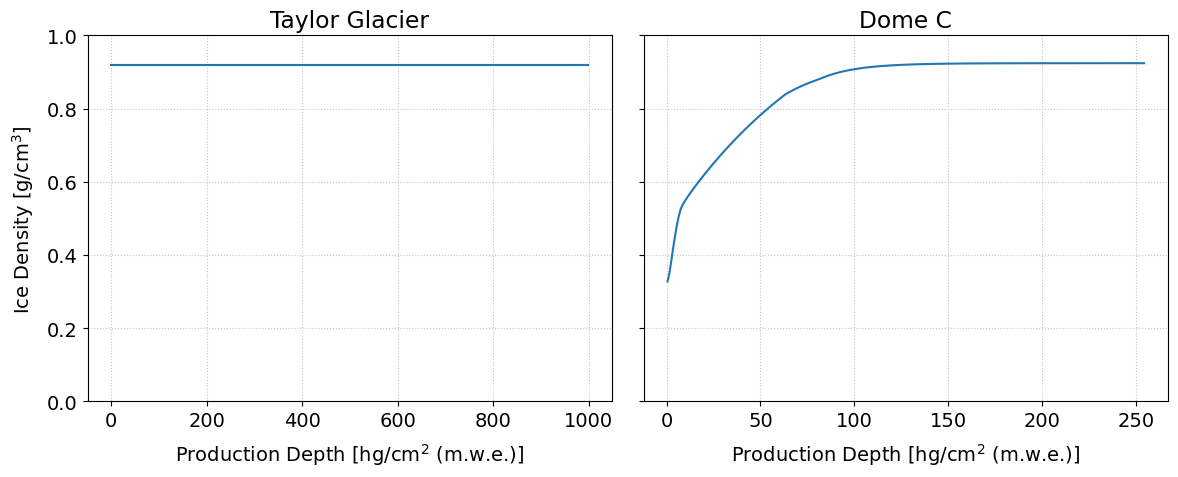

In [7]:
fig, axes = plt.subplots(1,2, figsize=(12,5), tight_layout=True, sharey=True)

# Plot depth, mass depth, and time
axes[0].plot(Prop_TG.h, Prop_TG.rho)
axes[0].set(
    xlabel=r'Production Depth [hg/cm$^2$ (m.w.e.)]',
    ylim=(0,1),
    ylabel='Ice Density [g/cm$^3$]',
    title='Taylor Glacier',
)
#axes[0].grid(which = 'minor', alpha = 0.3)
#axes[0].set_xticks(Prop_TG.h_bins, labels='', minor=True)
#axes[0].legend(loc='lower right', fontsize=10)

# Plot depth, mass depth, and time
axes[1].plot(Prop_DC.h, Prop_DC.rho)
#axes[1].plot(Prop_DC.age_grid, Prop_DC.h_grid, label='water-eq. depth')
axes[1].set(
    xlabel=r'Production Depth [hg/cm$^2$ (m.w.e.)]',
    ylim=(0,1),
    #ylabel='Depth [m]',
    title='Dome C',
)
#axes[1].grid(which = 'minor', alpha = 0.3)
#axes[1].set_xticks(Prop_DC.h_bins, labels='', minor=True)

#axes[1].legend(loc='lower right', fontsize=10)
#plt.suptitle('Production Grid Variables')
plt.show()

In [8]:
flow='best'
#flow = 'trim'
if flow=='best' or flow=='sample':
    flowpath = loadmat('matlab/MC_14CO_mod/flowpath_sample.mat')
    h_age = flowpath['h_age']
elif flow=='all':
    flowpath = loadmat('matlab/MC_14CO_mod/flowpath_all.mat')
    h_age = flowpath['h_age']
else:
    flowpath = loadmat('matlab/MC_14CO_mod/flowpath_trim.mat')
    h_age = np.swapaxes(flowpath['h_trim'], 1,2)
# h_age : ice parcel depth as a function of age [m]
#axis0 - sample depth
#axis1 - flowpath
#axis2 - ice parcel age

age = flowpath['age'][0]
# age : ice parcel ages [years]
#axis0 - ice parcel age
h_age.shape

x_DC = Prop_DC.h_prime(Prop_DC.h_accum.reshape((1,1,-1,1)), t.reshape((1,1,1,-1))) # accumulation depths
x_TG = np.expand_dims(interp1d(-age, -h_age.swapaxes(0,1), bounds_error=False, fill_value=-h_age[:,:,-1].T)(t), axis=1)

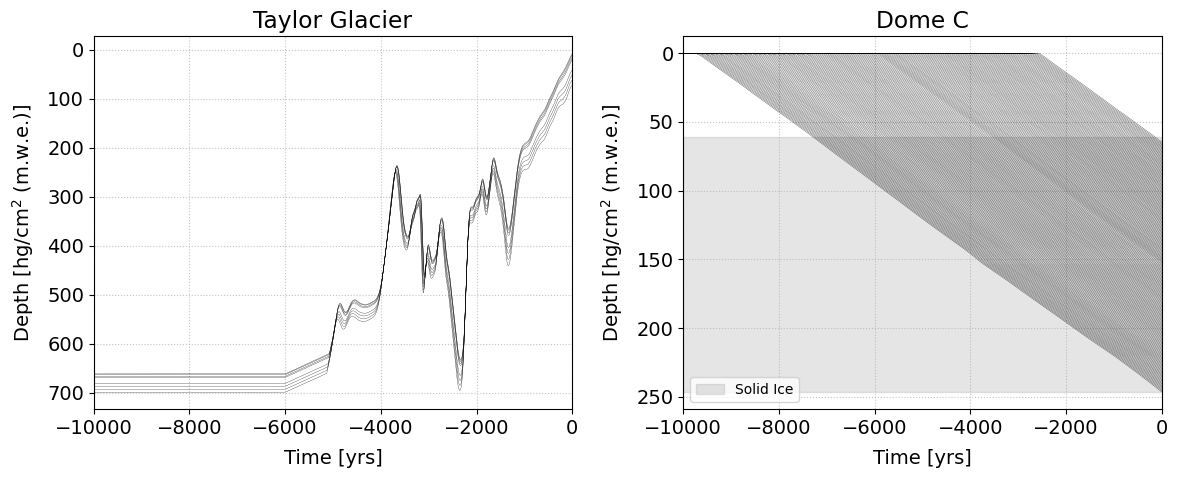

In [9]:
fig, axes = plt.subplots(1,2, figsize=(12,5), tight_layout=True, sharex = False, sharey=False)

axes[0].plot(t, x_TG[0,0].T, c='k', lw=0.2)
axes[0].set(
    xlabel='Time [yrs]',
    xlim=(-10000,0),
    ylabel=r'Depth [hg/cm$^2$ (m.w.e.)]',
    title='Taylor Glacier',
)
axes[0].yaxis.set_inverted(True)
#axes[0].legend(fontsize=10)

axes[1].axhspan(Prop_DC.z_to_h(Prop_DC.z_close), Prop_DC.h_samp_bins[-1,-1], color='grey', alpha=0.2, label='Solid Ice')
axes[1].plot(t, x_DC[0,0].T, c='k', lw=0.2)
axes[1].set(
    xlabel='Time [yrs]',
    xlim=(-10000,0),
    ylabel=r'Depth [hg/cm$^2$ (m.w.e.)]',
    title='Dome C',
)
axes[1].legend(fontsize=10)
axes[1].yaxis.set_inverted(True)

#plt.suptitle('Ice Parcel Accumulation Depths over Time')
plt.show()

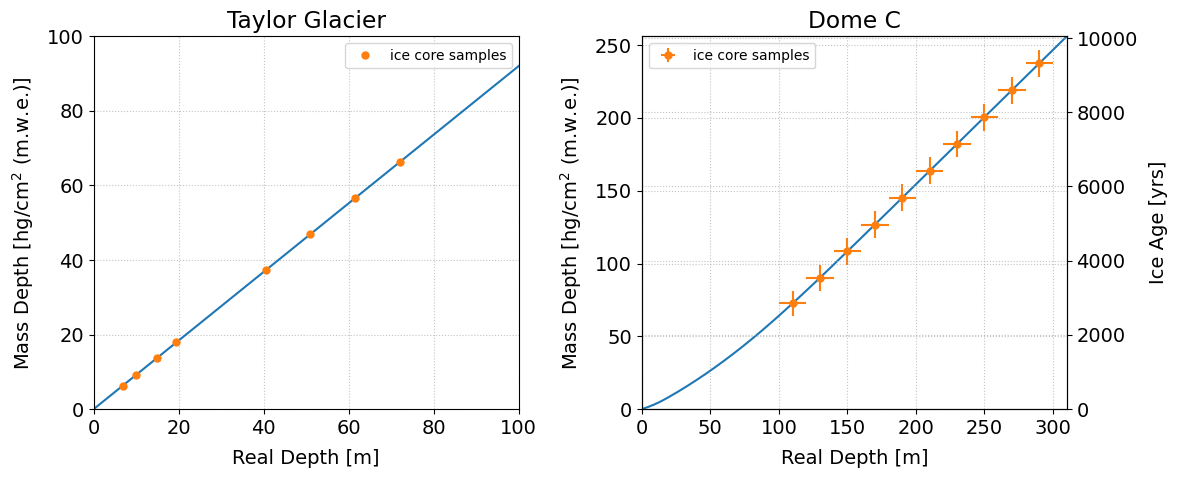

In [10]:
fig, axes = plt.subplots(1,2, figsize=(12,5), tight_layout=True)

# Plot depth, mass depth, and time
axes[0].plot(Prop_TG.z_grid, Prop_TG.h_grid)
axes[0].errorbar(z_samp_TG, Prop_TG.z_to_h(z_samp_TG), fmt='.', ms=10, label='ice core samples')
axes[0].set(
    xlim=(0,100),
    xlabel=r'Real Depth [m]',
    ylim=(0,100),
    ylabel='Mass Depth [hg/cm$^2$ (m.w.e.)]',
    title='Taylor Glacier',
)
#axes[0].grid(which = 'minor', alpha = 0.3)
#axes[0].set_xticks(Prop_TG.h_bins, labels='', minor=True)
axes[0].legend(fontsize=10)

# Plot depth, mass depth, and time
axes[1].plot(Prop_DC.z_grid, Prop_DC.h_grid)
axes[1].errorbar(Prop_DC.z_samp, Prop_DC.h_samp, xerr=abs(Prop_DC.z_samp_bins-Prop_DC.z_samp), yerr=abs(Prop_DC.h_samp_bins-Prop_DC.h_samp), fmt='.', ms=10, label='ice core samples')
axes[1].set(
    xlim=(Prop_DC.z_grid[0], Prop_DC.z_grid[-1]),
    xlabel=r'Real Depth [m]',
    ylim=(Prop_DC.h_grid[0], Prop_DC.h_grid[-1]),
    ylabel='Mass Depth [hg/cm$^2$ (m.w.e.)]',
    title='Dome C',
)

ax2 = axes[1].twinx()
ax2.set(
    ylabel='Ice Age [yrs]',
    ylim=(Prop_DC.age_grid[0], Prop_DC.age_grid[-1]),
)
#axes[1].grid(which = 'minor', alpha = 0.3)
#axes[1].set_xticks(Prop_DC.h_bins, labels='', minor=True)

axes[1].legend(fontsize=10)
#plt.suptitle('Sample Depths')
plt.show()

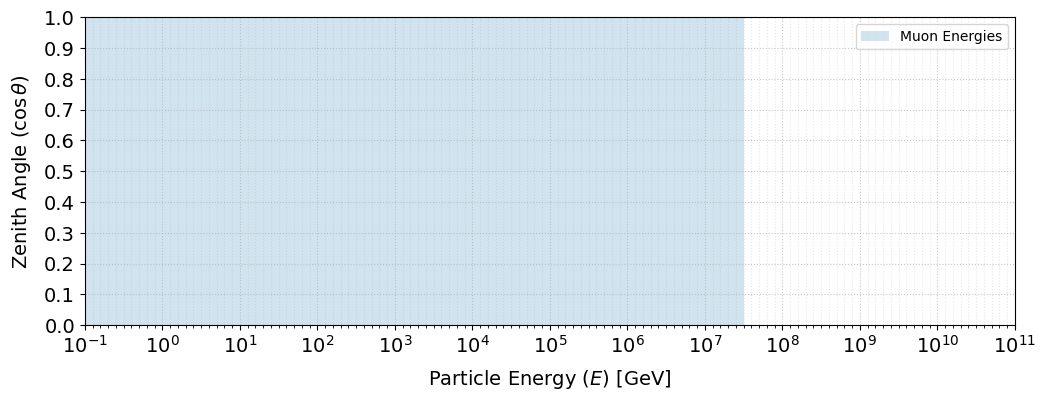

In [11]:
# plot Muon Energy & Angle bins
Prop=Prop_DC

fig, (ax) = plt.subplots(1,1, figsize=(12,4))
ax.axvspan(Prop.E_mu_bins[0], Prop.E_mu_bins[-1], alpha=0.2, label='Muon Energies')
ax.set(
    xlim=(Prop.E_bins[0],Prop.E_bins[-1]),
    xscale='log',
    #xticks = Prop.E_bins,
    xlabel=r'Particle Energy ($E$) [GeV]',
    ylim=(Prop.cosTH[-1],Prop.cosTH[0]),
    yticks = Prop.cosTH_bins,
    ylabel=r'Zenith Angle ($\cos\theta$)',
)
ax.legend(fontsize=10)

ax.grid(which = 'minor', alpha = 0.3)
ax.grid(which = 'major', alpha = 0.7)

ax.set_xticks(Prop.E_bins[np.arange(int((len(Prop.E_bins)+9)/10))*10], labels=[r'$10^{'+'{}'.format(int(i))+'}$' for i in np.rint(np.log10(Prop.E_bins[np.arange(int((len(Prop.E_bins)+9)/10))*10]))], minor=False)
ax.set_xticks(Prop.E_bins, labels='', minor=True)

#plt.suptitle('Particle Property Bins')
plt.show()

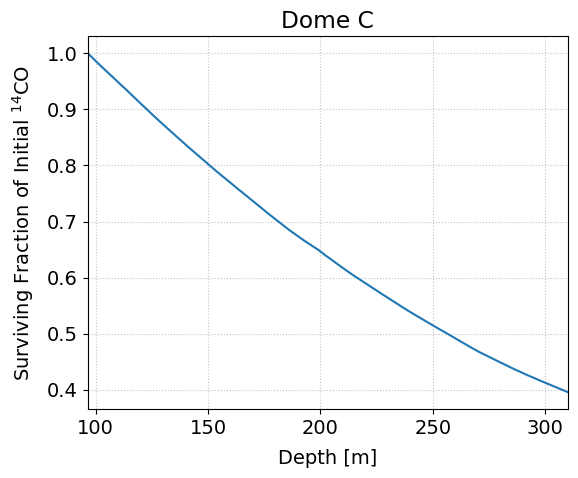

In [44]:
Prop = Prop_DC

fig, ax = plt.subplots(1,1, figsize=(6,5), tight_layout=True)

#ax.axvline(Prop.z_close, ls='--', c='grey', alpha=0.5)
cut = Prop.z_grid>Prop.z_close
ax.plot(Prop.z_grid[cut], np.exp((Prop.z_to_age(Prop.z_close)-Prop.age_grid[cut])*Prop.lambd))
ax.set(
    xlim=(Prop.z_close, Prop.z_grid[-1]),
    xlabel='Depth [m]',
    ylabel=r'Surviving Fraction of Initial $^{14}$CO',
    title='Dome C',
)
plt.show()

## Continuous Energy Loss (dE/dX)

In [48]:
interaction_model="SIBYLL-2.3c"

from MCEq import config
from MCEq.core import MCEqRun
import crflux.models as pm
from MCEq.geometry.density_profiles import GeneralizedTarget
config.debug_level = 0
config.enable_default_tracking = False
config.leading_process = "interactions"
config.e_min = Prop_DC.E_mu_bins[1]
config.e_max = Prop_DC.E_mu_bins[-1]
config.max_density = Prop_DC.rho_ice
config.dedx_material='ice'
medium = 'ice'

target = GeneralizedTarget(len_target=100, env_density = 0.92, env_name = 'ice')

mceq = MCEqRun(
    interaction_model=interaction_model,
    theta_deg = 0,
    density_model = target,
    medium=medium,
    primary_model = (pm.GaisserHonda, None),
)

mceq_dedx = -mceq.pman[-13].dEdX*100

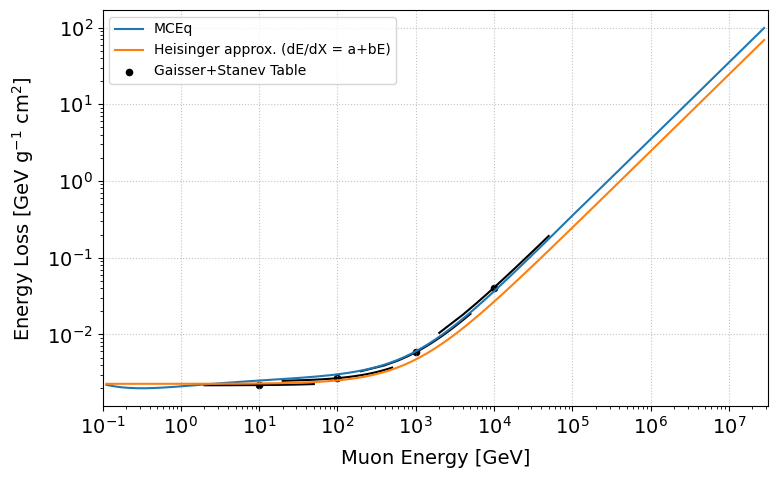

In [68]:
Prop = Prop_DC
E = Prop.E_mu

E_GS = np.array([10, 100, 1000, 10000]) # GeV
a_GS = np.array([2.17, 2.44, 2.68, 2.93])*1e-3 # GeV g^-1 cm^2
b_GS = np.array([1.66, 2.51, 3.17, 3.78])*1e-6 # g^-1 cm^2

fig, ax = plt.subplots(1,1, figsize=(8,5), tight_layout=True)

for i,e in enumerate(E_GS):
    x = (np.arange(25)+1)/5*e
    plt.plot(x, a_GS[i]+b_GS[i]*x, c='k')
plt.plot(E, mceq_dedx/100, label='MCEq')
#plt.plot(mceq._energy_grid.c, -mceq.pman[13].dEdX)
ax.plot(E, (Prop.a + Prop.b*E)/100, label='Heisinger approx. (dE/dX = a+bE)')
ax.scatter(E_GS, a_GS+b_GS*E_GS, c='k', s=20, label='Gaisser+Stanev Table')
ax.set(
    xscale='log',
    xlim=(Prop.E_mu_bins[0],Prop.E_mu_bins[-1]),
    xlabel='Muon Energy [GeV]',
    yscale='log',
    ylabel=r'Energy Loss [GeV g$^{-1}$ cm$^2$]',
)
ax.legend(fontsize=10)
#plt.title(r'Continuous Muon Energy Loss ($dE/dX$)')
plt.show()

## Production Rates

In [69]:
alphas = np.arange(0.67,1.01,0.01)

def setup_models(Prop, density_models):
    # setup lists of models

    # primary CRs
    primary = [(F.get_primary,
                [(pm.GlobalSplineFitBeta, None),
                 (pm.HillasGaisser2012, "H3a"),
                 (pm.HillasGaisser2012, "H4a"),
                 (pm.PolyGonato, False),
                 (pm.GaisserStanevTilav, "3-gen"),
                 (pm.GaisserStanevTilav, "4-gen"),
                 (pm.CombinedGHandHG, "H3a"),
                 (pm.ZatsepinSokolskaya, "pamela"), 
                 (pm.ZatsepinSokolskaya, "default"),
                 (pm.GaisserHonda, None),
                 (pm.Thunman, None), 
                 (pm.SimplePowerlaw27, None)
                ], 
                ['GlobalSplineFitBeta',
                 'HillasGaisser2012 H3a',
                 'HillasGaisser2012 H4a',
                 'PolyGonato',
                 'GaisserStanevTilav 3-gen',
                 'GaisserStanevTilav 4-gen',
                 'CombinedGHandHG H3a',
                 'ZatsepinSokolskaya pamela',
                 'ZatsepinSokolskaya default',
                 'GaisserHonda',
                 'Thunman',
                 'SimplePowerlaw27'
                ]),
              ]

    interaction_models = [
         "SIBYLL23CPP",
         "SIBYLL23C03",
         "SIBYLL-2.3c",
         "SIBYLL-2.3",
         "SIBYLL-2.1",
         "EPOS-LHC",
         "QGSJET-II-04",
         "QGSJETII03",
         "QGSJET01C",
         "DPMJETIII306",
         'DPMJETIII191',
    ]
    #density_models = [('CORSIKA', ('USStd', None)), ('CORSIKA',('SouthPole', 'December'))]
    #density_model = ('CORSIKA',('SouthPole', 'December'))
    #density_model = ('MSIS00', ('SouthPole', 'January'))

    # atmospheric muons
    atm = [#(F.judge_nash, (), 'JN-fit'), # NOTE this fit is for SEA-LEVEL
           (F.daemonflux_atm, (), 'daemonflux'), # NOTE this fit is for SEA-LEVEL
           #(F.MCEq_atm, [(i_m, d_m) for d_m in density_models for i_m in interaction_models],
            #['MCEq-atm-{}-{}'.format(i_m, d_m) for d_m in density_models for i_m in interaction_models],),
          ]
    #atm = []

    # underice muons
    ice = [#(F.Heisinger_ice, (True), 'H-ice'),
           #(F.proposal_ice, (), 'proposal'),
           #(F.Heisinger_ice, (), 'GS-ice'),
           #(F.Heisinger_ice, (False,1), 'GS-ice-linear'),
           #(F.Heisinger_ice, (False,2), 'GS-ice-loop'),
           (F.cont_loss, [(), (Prop_DC.a+Prop_DC.b*Prop_DC.E_mu,0), (Prop_DC.a+Prop_DC.b*Prop_DC.E_mu,1), (mceq_dedx,0), (mceq_dedx,1)], ['cont-loss-GS', 'cont-loss-GS0', 'cont-loss-GS1', 'cont-loss-MCEq0', 'cont-loss-MCEq1']),
           #(F.cont_loss, [(), (mceq_dedx,1)], ['contloss-GS', 'contloss-mceq']),
           (F.MCEq_mu_ice, [(dEdX, ignore_decays) for dEdX in ['Heisinger', None] for ignore_decays in [False, True]],
            ['MCEq-mu-ice-{}-{}'.format(dEdX, ignore_decays) for dEdX in ['Heisinger', None] for ignore_decays in [False, True]],),
           #(F.MCEq_ice, [(i_m) for i_m in interaction_models], ['MCEq_ice' for i_m in interaction_models],),
           #(F.MCEq_atmice, [(i_m, d_m) for d_m in density_models for i_m in interaction_models], ['{}-{}'.format(i_m, d_m) for d_m in density_models for i_m in interaction_models],),
           #(F.Heisinger_norm, [(0),()], ['fluxfit-H','fluxfit-B']),
          ]

    # 14C production rates

    prod = [
        #(F.Dyonisius_prod, [(None, None, alpha) for alpha in alphas], ['alpha={:.2f}'.format(alpha) for alpha in alphas]),
        #(F.Heisinger_full, [(0),()], ['Heisinger','Balco']),
    ]
    
    # Now we load our desired models into the Propagator
    Prop.set_models(primary=primary,
                    atm=atm,
                    ice=ice,
                    prod=prod)
    
    return

In [70]:
setup_models(Prop_DC, density_models_DC)
setup_models(Prop_TG, density_models_TG)

In [71]:
run_models = True
save_models = False
load_index = 0

In [72]:
tag='DomeC'
if run_models:
    Prop_DC.calculate()
    if save_models:
        Prop_DC.save_prod_to_csv(tag=tag)
    P_14C_DC = np.copy(Prop_DC.Phi['prod'])
    model_names_DC = list(Prop_DC.model_names['prod'])
else:
    P_14C_DC, model_names_DC = Prop_DC.load_prod_from_csv(tag=tag, i=load_index)

Running primary stage...
GlobalSplineFitBeta
HillasGaisser2012 H3a
HillasGaisser2012 H4a
PolyGonato
GaisserStanevTilav 3-gen
GaisserStanevTilav 4-gen
CombinedGHandHG H3a
ZatsepinSokolskaya pamela
ZatsepinSokolskaya default
GaisserHonda
Thunman
SimplePowerlaw27
primary stage complete

Running atm stage...
daemonflux
atm stage complete

Running ice stage...
_cont-loss-GS


100%|██████████████████████████████████████████████████████████████████████████████████| 10/10 [00:00<00:00, 791.59it/s]


_cont-loss-GS0


100%|██████████████████████████████████████████████████████████████████████████████████| 10/10 [00:00<00:00, 808.74it/s]


_cont-loss-GS1


...

_MCEq-mu-ice-None-False


100%|██████████████████████████████████████████████████████████████████████████| 51256/51256 [00:02<00:00, 24570.63it/s]


_MCEq-mu-ice-None-True


100%|██████████████████████████████████████████████████████████████████████████| 51256/51256 [00:01<00:00, 26297.36it/s]

ice stage complete

Running prod stage...
prod stage complete

Running CO stage...
CO stage complete



In [73]:
tag='TaylorGlacier'
if run_models:
    Prop_TG.calculate()
    if save_models:
        Prop_TG.save_prod_to_csv(tag=tag)
    P_14C_TG = np.copy(Prop_TG.Phi['prod'])
    model_names_TG = list(Prop_DC.model_names['prod'])
else:
    P_14C_TG, model_names_TG = Prop_TG.load_prod_from_csv(tag=tag, i=load_index)

Running primary stage...
GlobalSplineFitBeta
HillasGaisser2012 H3a
HillasGaisser2012 H4a
PolyGonato
GaisserStanevTilav 3-gen
GaisserStanevTilav 4-gen
CombinedGHandHG H3a
ZatsepinSokolskaya pamela
ZatsepinSokolskaya default
GaisserHonda
Thunman
SimplePowerlaw27
primary stage complete

Running atm stage...
daemonflux
atm stage complete

Running ice stage...
_cont-loss-GS


100%|██████████████████████████████████████████████████████████████████████████████████| 10/10 [00:00<00:00, 227.58it/s]


_cont-loss-GS0


100%|██████████████████████████████████████████████████████████████████████████████████| 10/10 [00:00<00:00, 234.76it/s]


_cont-loss-GS1


...

_MCEq-mu-ice-None-False


100%|████████████████████████████████████████████████████████████████████████| 200800/200800 [00:08<00:00, 23896.34it/s]


_MCEq-mu-ice-None-True


100%|████████████████████████████████████████████████████████████████████████| 200800/200800 [00:08<00:00, 24816.96it/s]

ice stage complete

Running prod stage...
prod stage complete

Running CO stage...
CO stage complete



In [74]:
P_14C = np.concatenate((P_14C_DC, P_14C_TG), axis=-1)
model_names = model_names_DC

### Primary Spectra

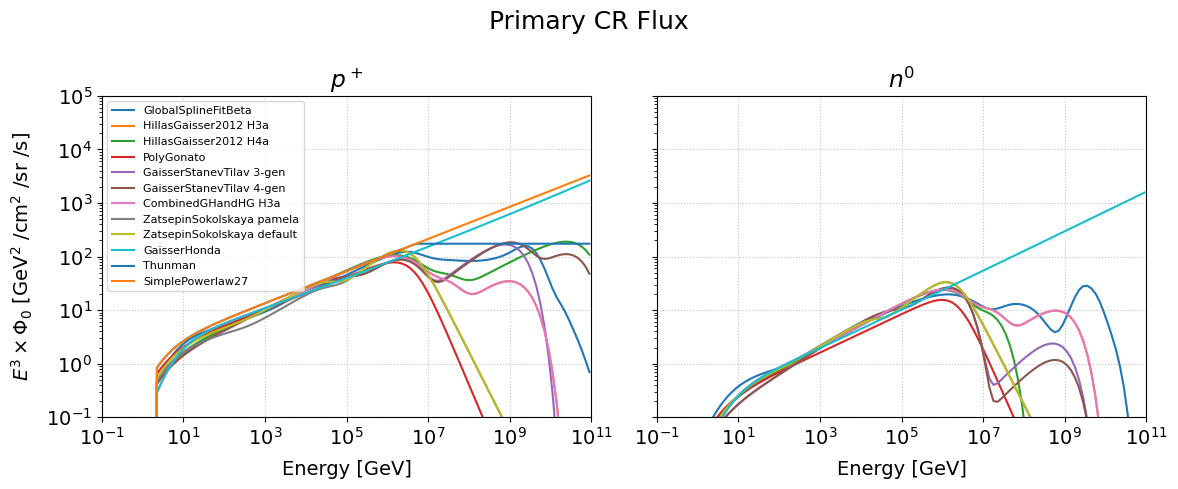

In [75]:
# plot primary flux
Epow = 3

Prop=Prop_DC # It shouldn't matter if it's Dome C or Taylor Glacier

if len(Prop.Phi['primary'])>0:
    fig, (ax1,ax2) = plt.subplots(1,2, figsize=(12,5), tight_layout=True, sharey=True, sharex=True)
    for i,p in enumerate(Prop.Phi['primary']):
        ax1.plot(Prop.E, p[0]*Prop.E**Epow, label=Prop.model_names['primary'][i])
        ax2.plot(Prop.E, p[1]*Prop.E**Epow)
    ax1.set(xlim = (Prop.E_bins[0], Prop.E_bins[-1]),
           xlabel = 'Energy [GeV]',
           xscale = 'log',
           ylabel = r'$E^{} \times \Phi_0$ [GeV$^{}$ /cm$^2$ /sr /s]'.format(Epow, Epow-1),
           ylim = (1e-1, 1e+5),
           yscale = 'log',
           title = r'$p^+$',
          )
    ax1.legend(fontsize=8)
    ax2.set(xlim = (Prop.E_bins[0], Prop.E_bins[-1]),
           xlabel = 'Energy [GeV]',
           xscale = 'log',
           #yscale = 'log',
           title = r'$n^0$',
          )
    plt.suptitle('Primary CR Flux', size=18)
    plt.show()

### Atmospheric Spectra

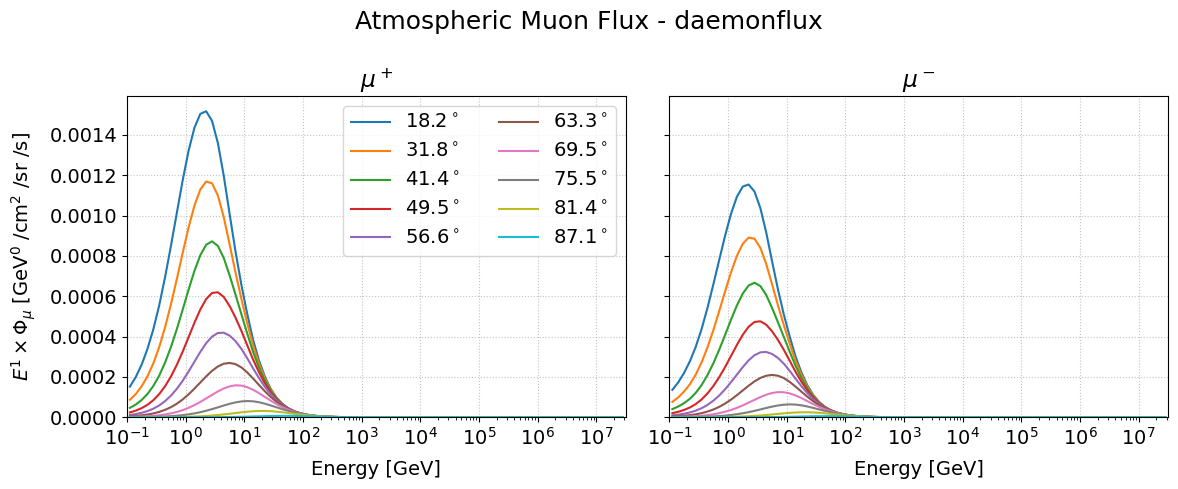

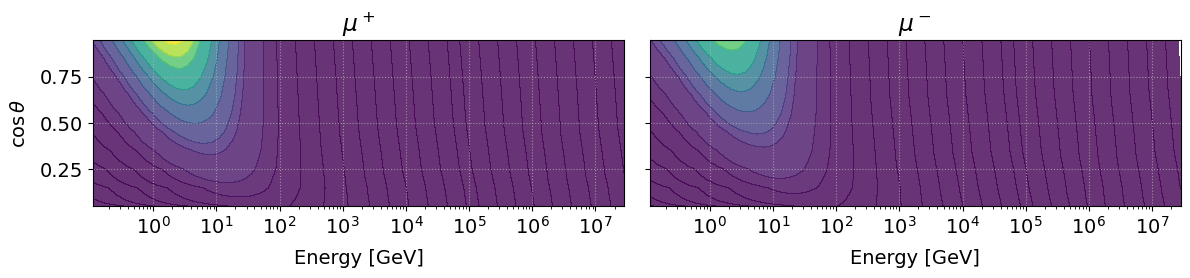

In [76]:
# Plot atmospheric muon spectra
Epow = 1

Prop=Prop_DC

if len(Prop.Phi['atm'])>0 and len(Prop.Phi['atm'])<100:
    for j in range(len(Prop.Phi['atm'])):
        fig, (ax1,ax2) = plt.subplots(1,2, figsize=(12,5), tight_layout=True, sharex = True, sharey=True)
        for i,cth in enumerate(Prop.cosTH):
            ax1.plot(Prop.E_mu, Prop.Phi['atm'][j,i,0]*Prop.E_mu**Epow, label=r'{:.1f}$^\circ$'.format(np.arccos(cth)*180/np.pi))
            ax2.plot(Prop.E_mu, Prop.Phi['atm'][j,i,1]*Prop.E_mu**Epow)
        ax1.set(xlim = (Prop.E_mu_bins[0], Prop.E_mu_bins[-1]),
                xscale = 'log',
                xlabel = 'Energy [GeV]',
                title = r'$\mu^+$',
                ylim = (np.min(Prop.Phi['atm']*Prop.E_mu**Epow), np.max(Prop.Phi['atm']*Prop.E_mu**Epow)*1.05),
                #yscale = 'log',
                ylabel = r'$E^{} \times \Phi_\mu$ [GeV$^{}$ /cm$^2$ /sr /s]'.format(Epow, Epow-1)
              )
        ax1.legend(ncol=2)
        ax2.set(xlim = (Prop.E_mu_bins[0], Prop.E_mu_bins[-1]),
                xscale = 'log',
                xlabel = 'Energy [GeV]',
                title = r'$\mu^-$',
              )
        plt.suptitle('Atmospheric Muon Flux - {}'.format(Prop.model_names['atm'][j]), size=18)
        plt.show()

        #fig, (ax1,ax2) = plt.subplots(1,2, figsize=(12,3), tight_layout=True, sharex=True, sharey=True)
        #ax1.pcolormesh(Prop.E_mu_bins, Prop.cosTH_bins, Prop.Phi_atm[j,0,:,0]*Prop.E_mu**Epow,
                       #norm = mpl.colors.PowerNorm(gamma=0.2))
        #ax2.pcolormesh(Prop.E_mu_bins, Prop.cosTH_bins, Prop.Phi_atm[j,0,:,1]*Prop.E_mu**Epow,
                       #norm = mpl.colors.PowerNorm(gamma=0.2))
        #ax1.set(xscale = 'log',
                #xlabel = 'Energy [GeV]',
                #ylabel = r'$\cos\theta$',
                #title = r'$\mu^+$',
              #)
        #ax2.set(xscale = 'log',
                #xlabel = 'Energy [GeV]',
                #title = r'$\mu^-$',
              #)
        #plt.show()


        fig, (ax1,ax2) = plt.subplots(1,2, figsize=(12,3), tight_layout=True, sharex=True, sharey=True)

        N_levels = 30
        levels = np.unique(np.sort(Prop.Phi['atm'][j,0,0]*Prop.E_mu**Epow)[np.linspace(0,len(Prop.E_mu)-1,N_levels, dtype=int)])
        #levels = np.linspace(np.min(Prop.Phi_atm[j,0]*Prop.E_mu**Epow), np.max(Prop.Phi_atm[j,0]*Prop.E_mu**Epow), N_levels)

        cf1 = ax1.contourf(Prop.E_mu, Prop.cosTH, Prop.Phi['atm'][j,:,0]*Prop.E_mu**Epow,
                       levels=levels, alpha=0.8)
        cf2 = ax2.contourf(Prop.E_mu, Prop.cosTH, Prop.Phi['atm'][j,:,1]*Prop.E_mu**Epow,
                       levels=levels, alpha=0.8)
        ax1.set(xscale = 'log',
                xlabel = 'Energy [GeV]',
                ylabel = r'$\cos\theta$',
                title = r'$\mu^+$',
              )
        ax2.set(xscale = 'log',
                xlabel = 'Energy [GeV]',
                title = r'$\mu^-$',
              )
        #fig.colorbar(cf1)
        #fig.colorbar(cf2)
        plt.show()

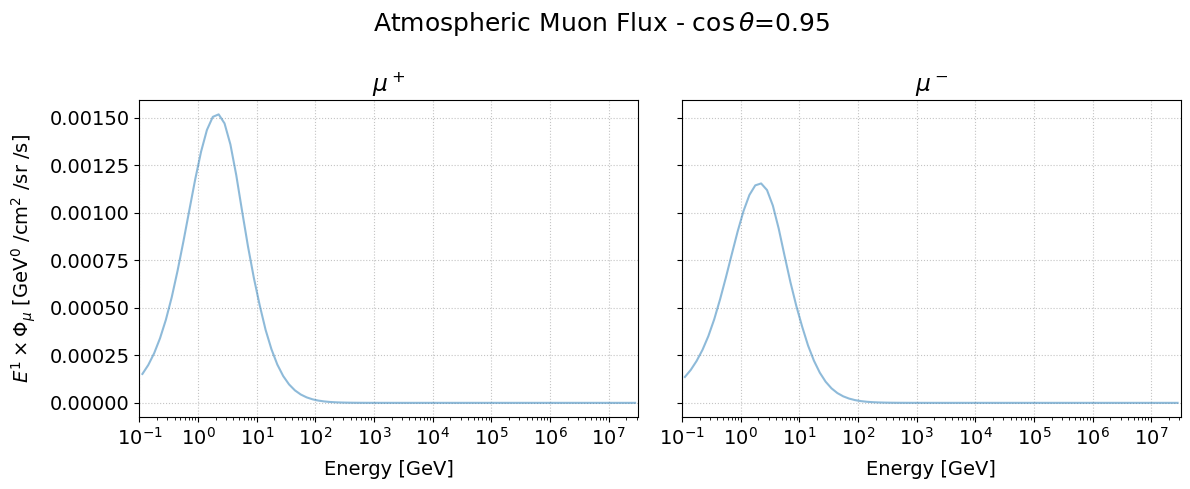

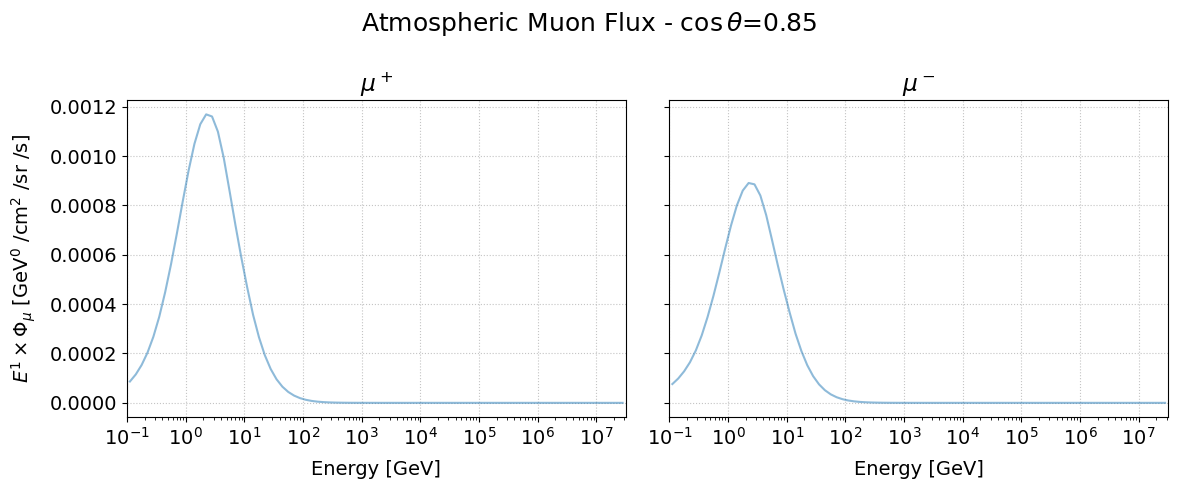

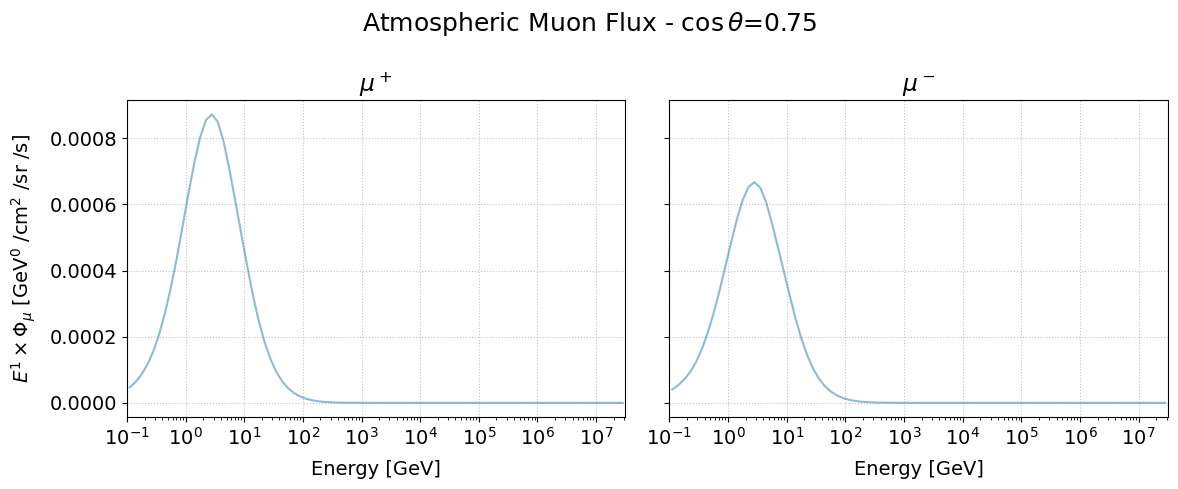

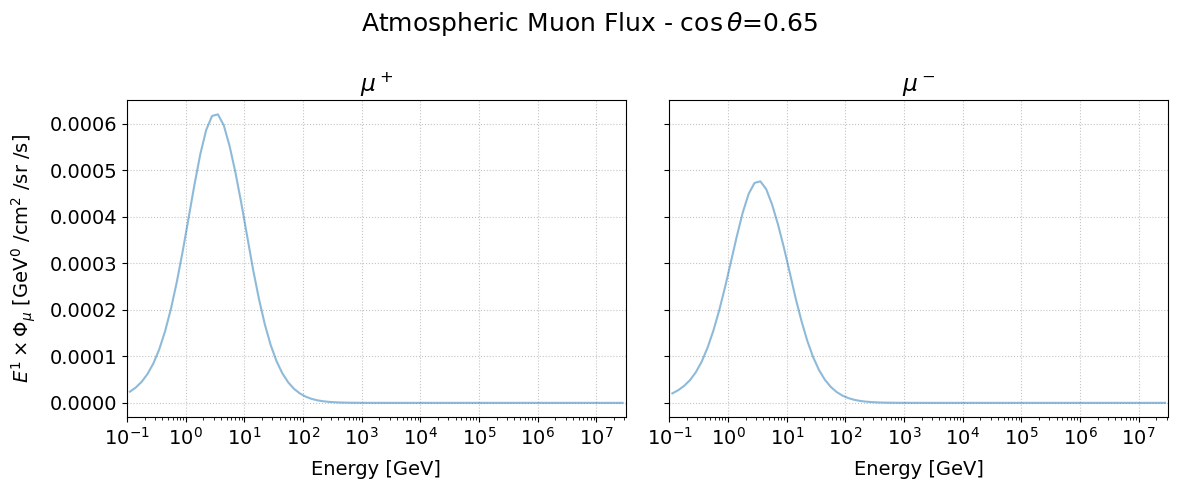

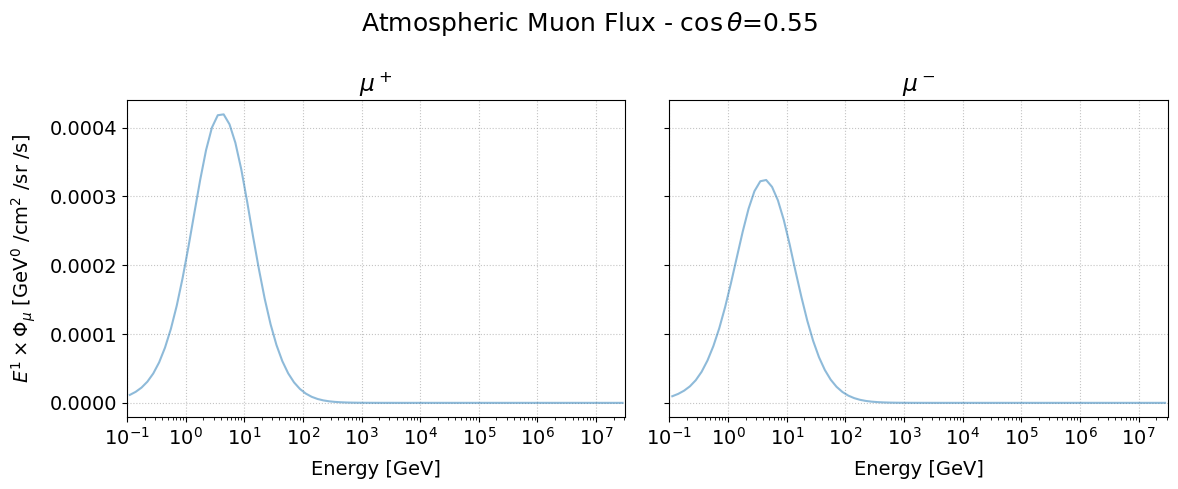

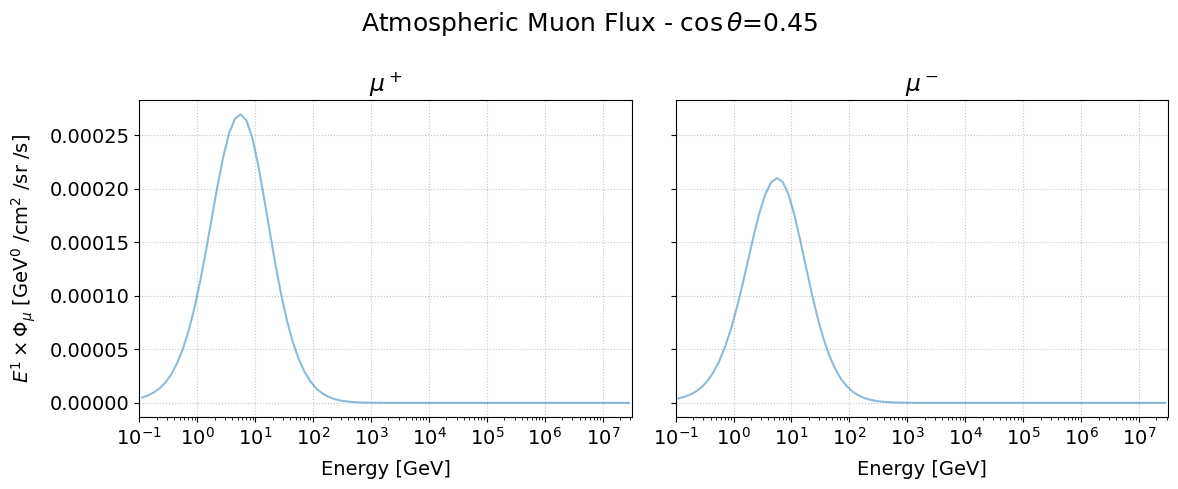

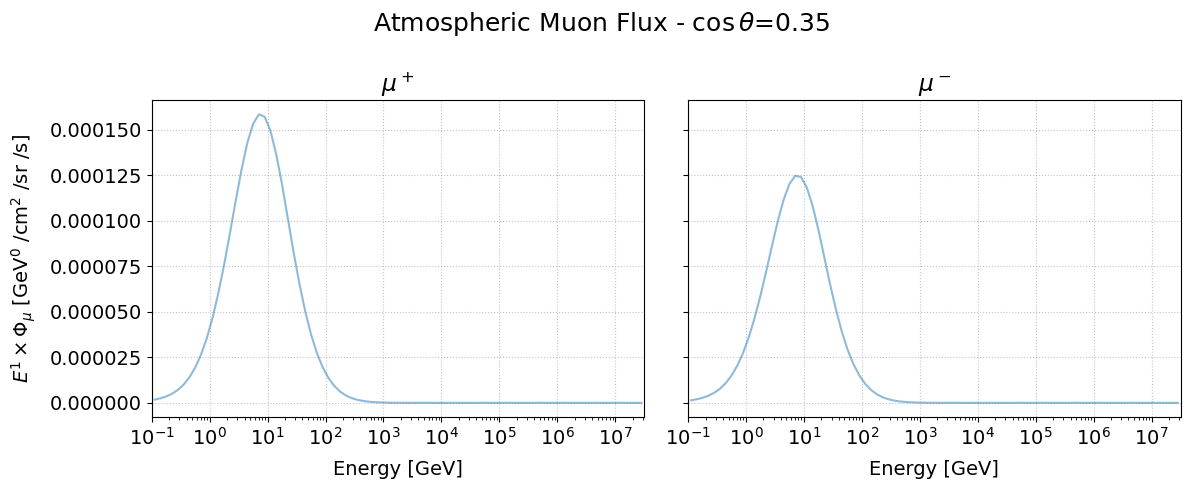

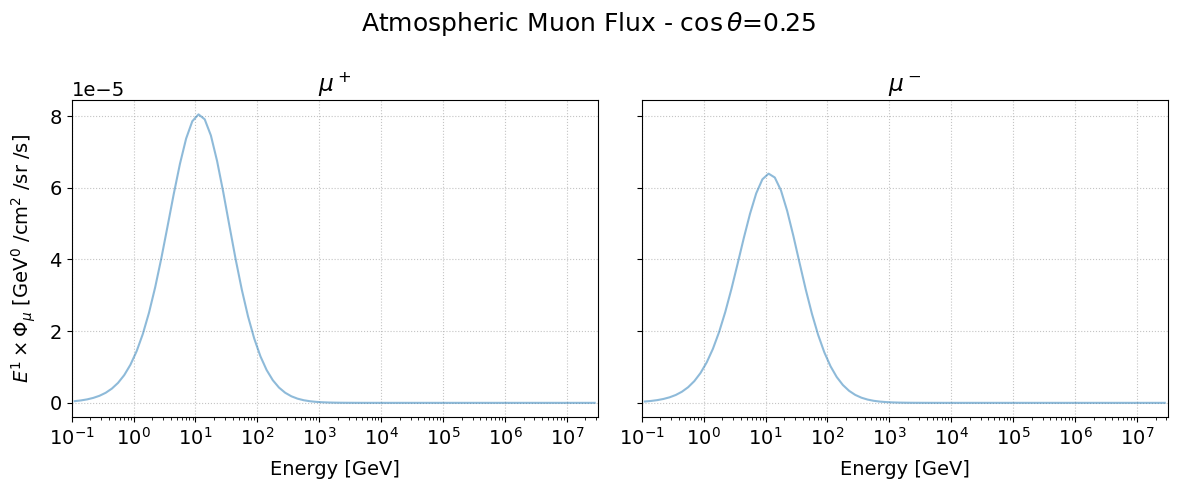

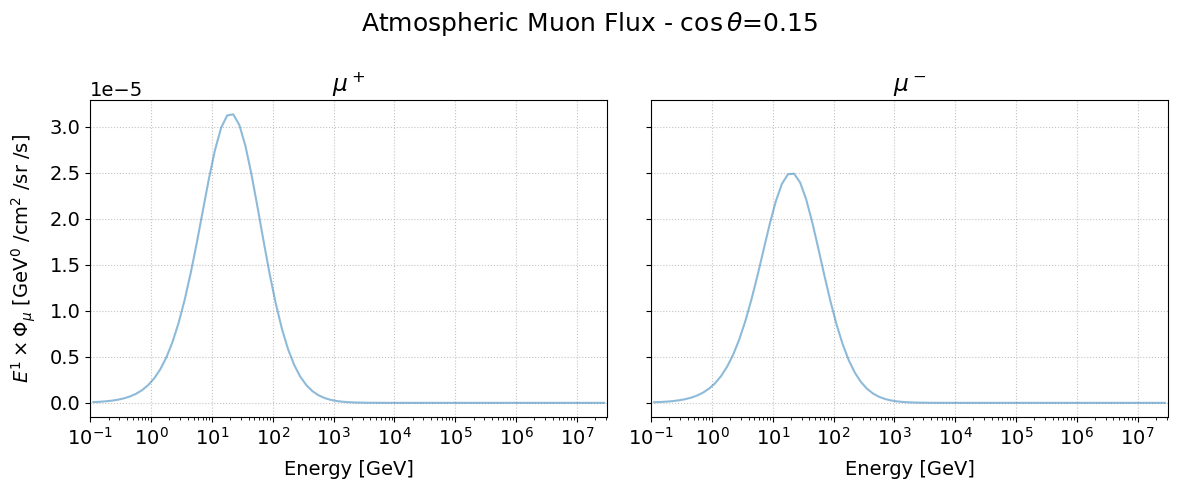

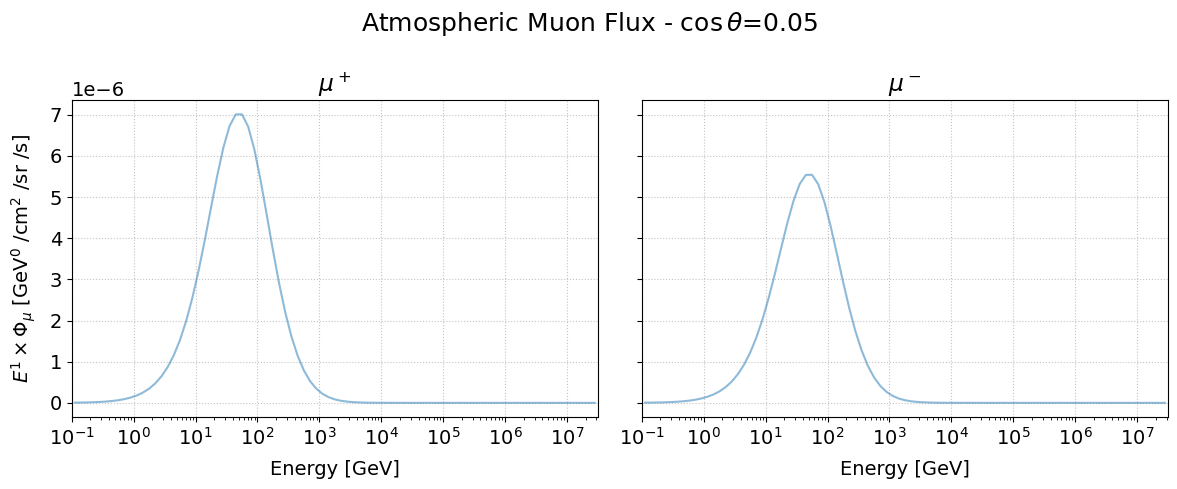

In [77]:
# Plot atmospheric muon spectra
Epow = 1

Prop=Prop_DC

if len(Prop.Phi['atm'])>0:
    for j,cth in enumerate(Prop.cosTH):
        fig, (ax1,ax2) = plt.subplots(1,2, figsize=(12,5), tight_layout=True, sharex = True, sharey=True)
        for i,p in enumerate(Prop.Phi['atm']):
            ax1.plot(Prop.E_mu, p[j,0]*Prop.E_mu**Epow, label=Prop.model_names['atm'][i], alpha=0.5)
            ax2.plot(Prop.E_mu, p[j,1]*Prop.E_mu**Epow, alpha=0.5)
        ax1.set(xlim = (Prop.E_mu_bins[0], Prop.E_mu_bins[-1]),
                xscale = 'log',
                xlabel = 'Energy [GeV]',
                title = r'$\mu^+$',
                #ylim = (np.min(Prop.Phi['atm']*Prop.E_mu**Epow), np.max(Prop.Phi['atm']*Prop.E_mu**Epow)*1.05),
                #yscale = 'log',
                ylabel = r'$E^{} \times \Phi_\mu$ [GeV$^{}$ /cm$^2$ /sr /s]'.format(Epow, Epow-1)
              )
        #ax1.legend(ncol=2)
        ax2.set(xlim = (Prop.E_mu_bins[0], Prop.E_mu_bins[-1]),
                xscale = 'log',
                xlabel = 'Energy [GeV]',
                title = r'$\mu^-$',
              )
        plt.suptitle(r'Atmospheric Muon Flux - $\cos\theta$='+'{:.2f}'.format(cth), size=18)
        plt.show()

### Underground Spectra

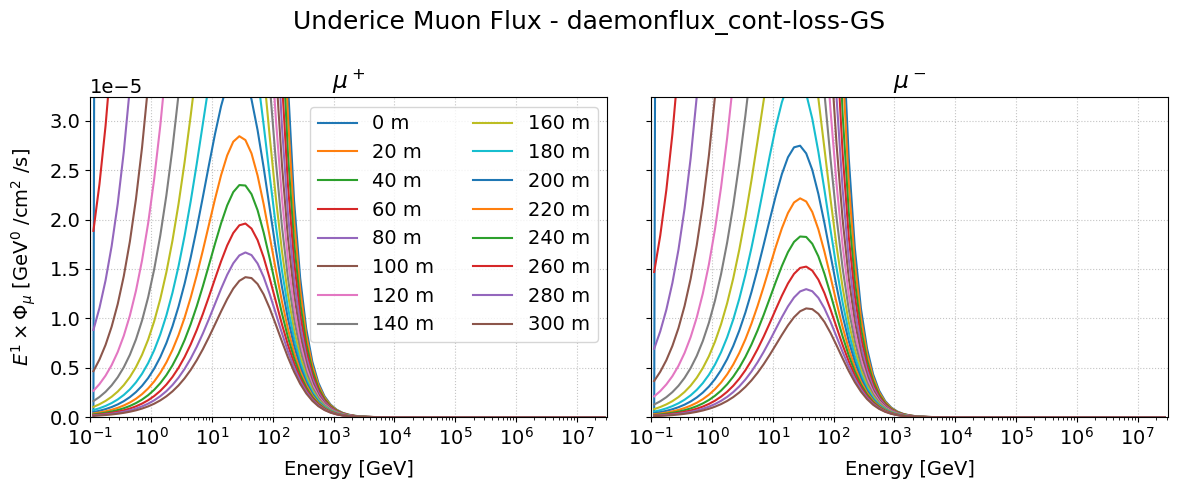

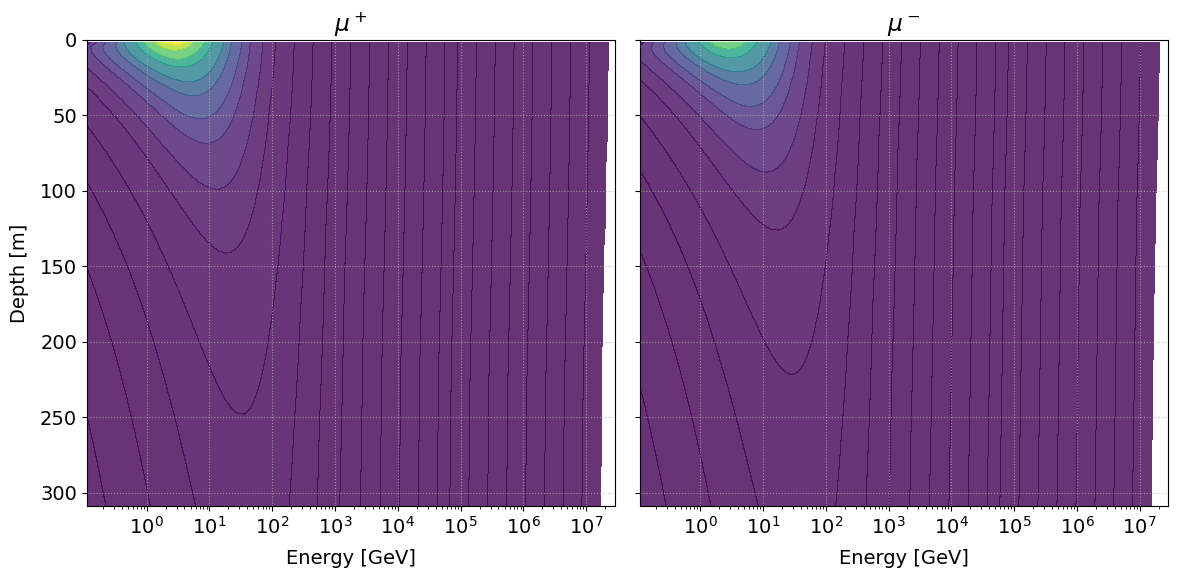

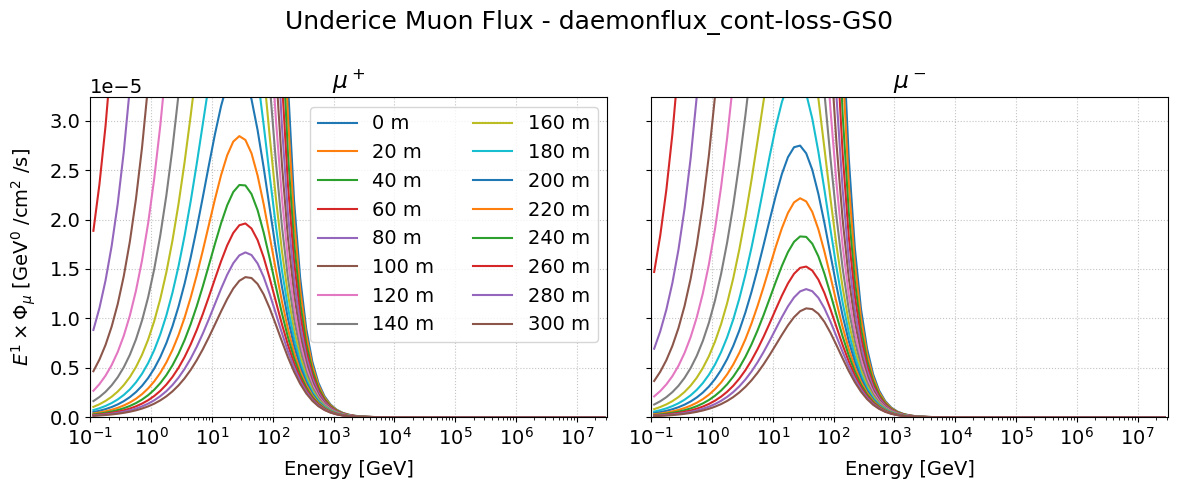

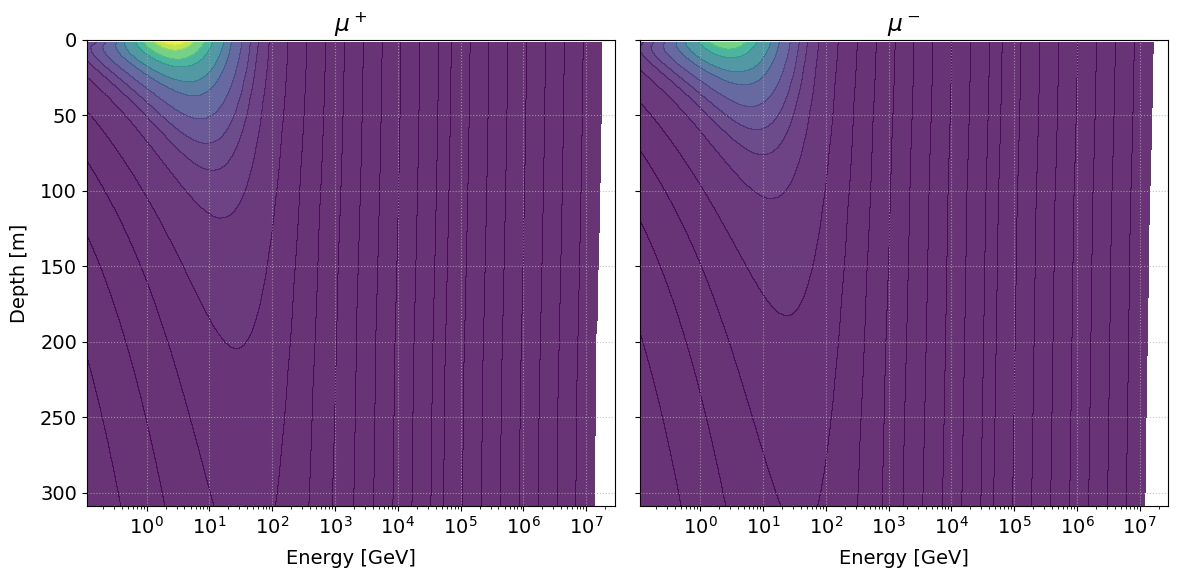

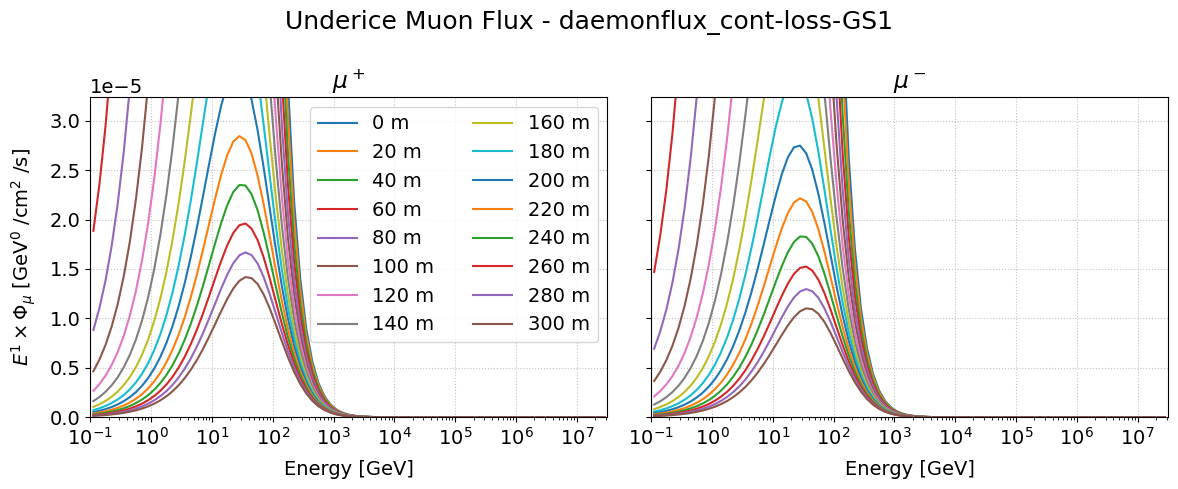

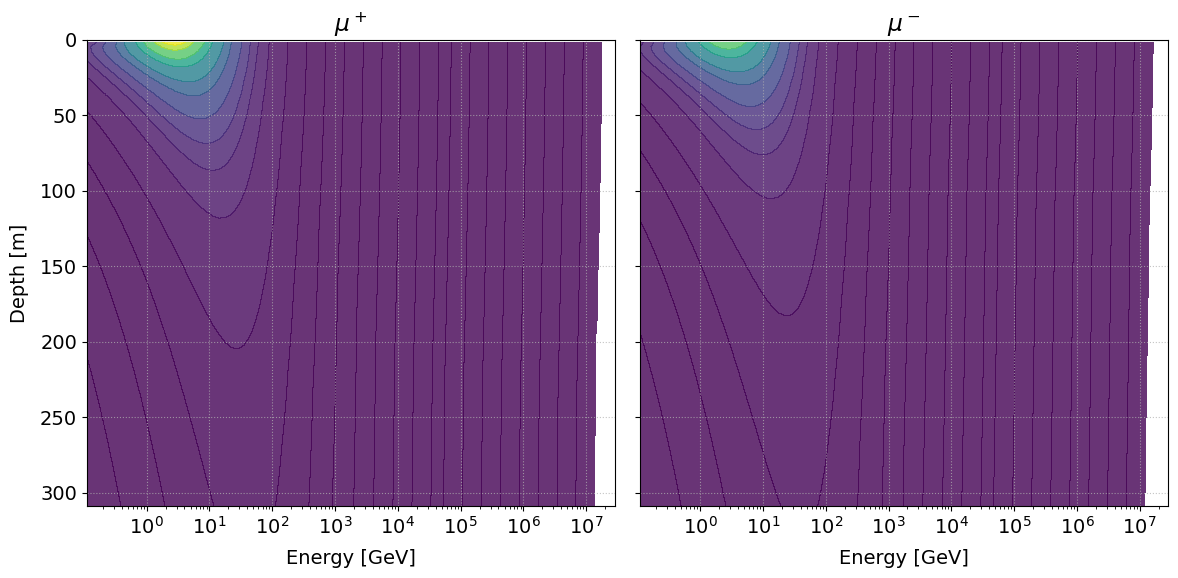

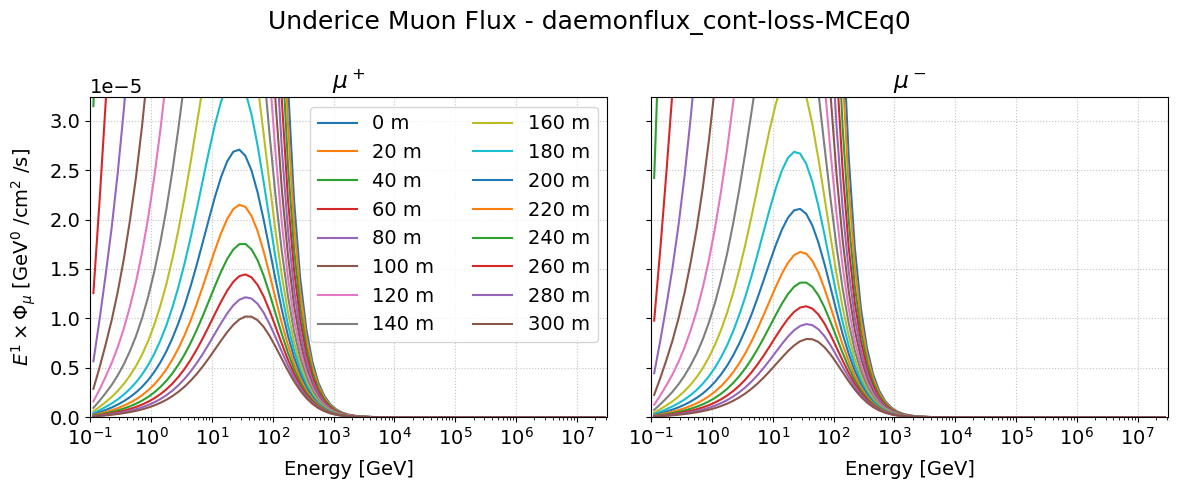

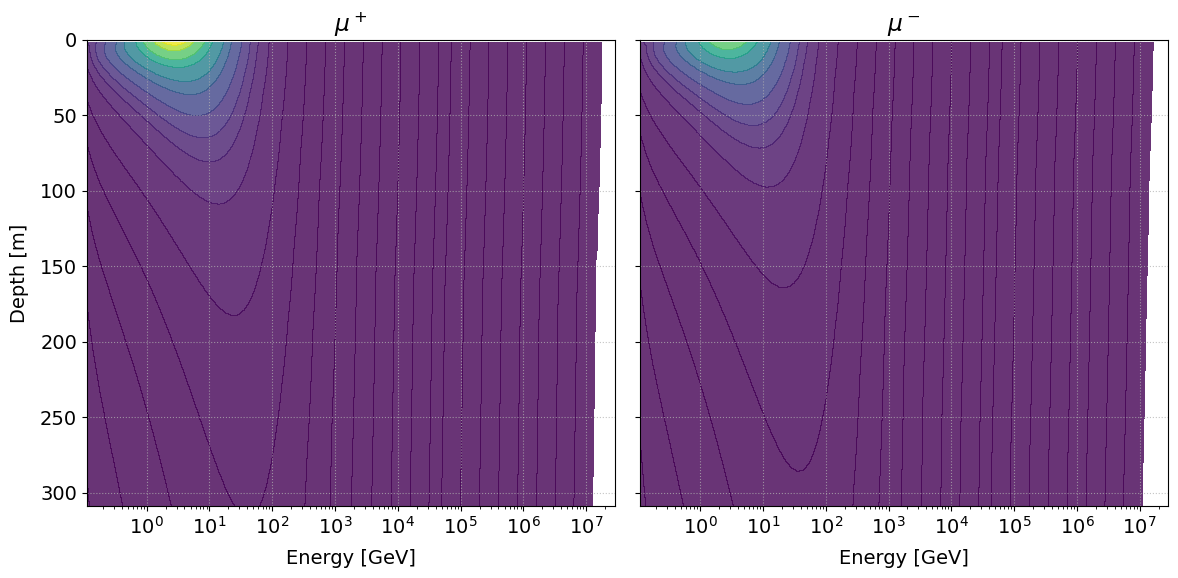

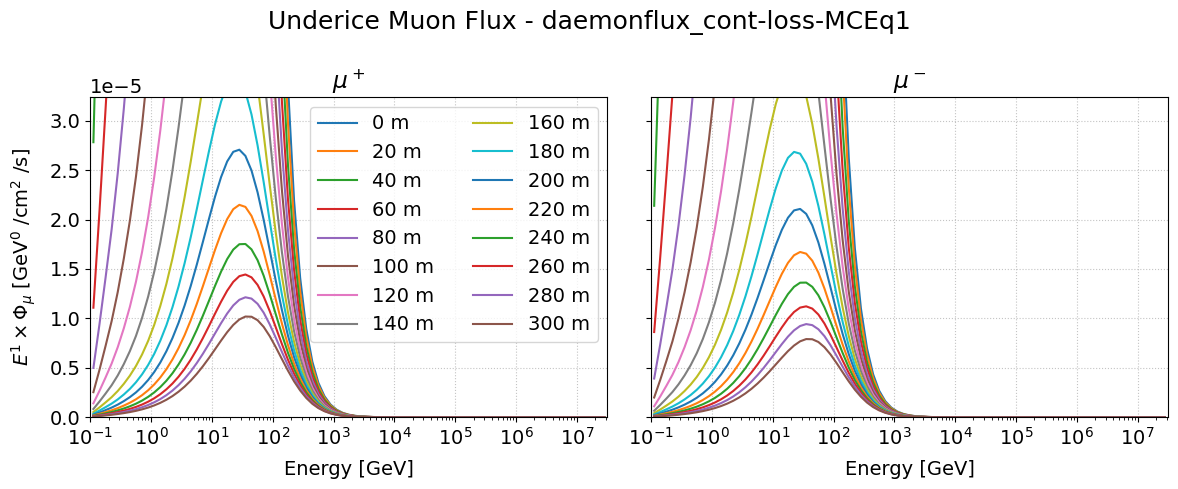

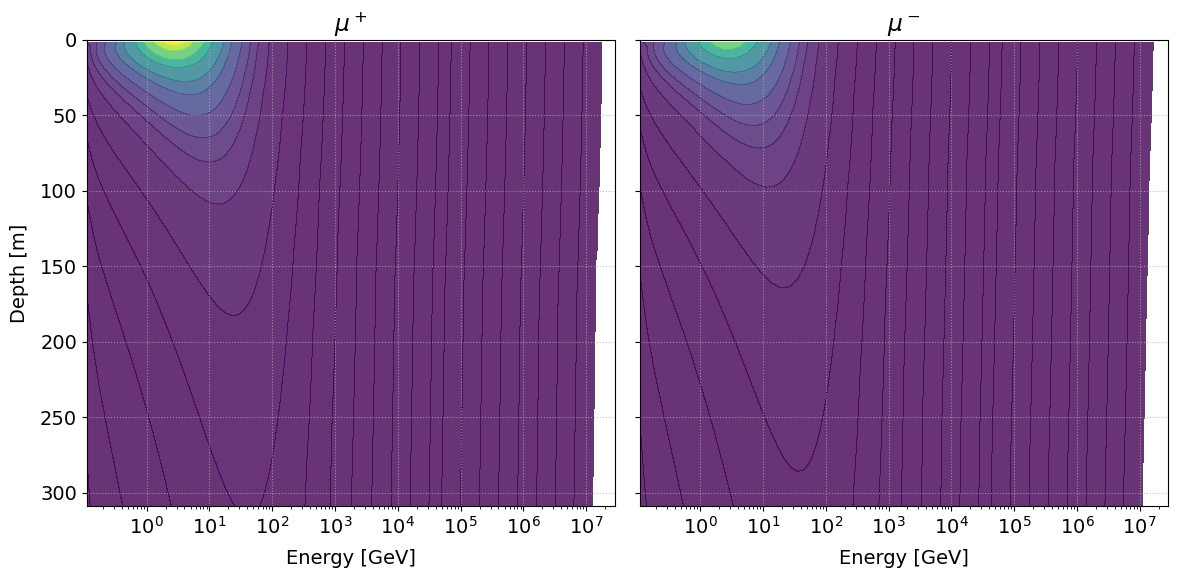

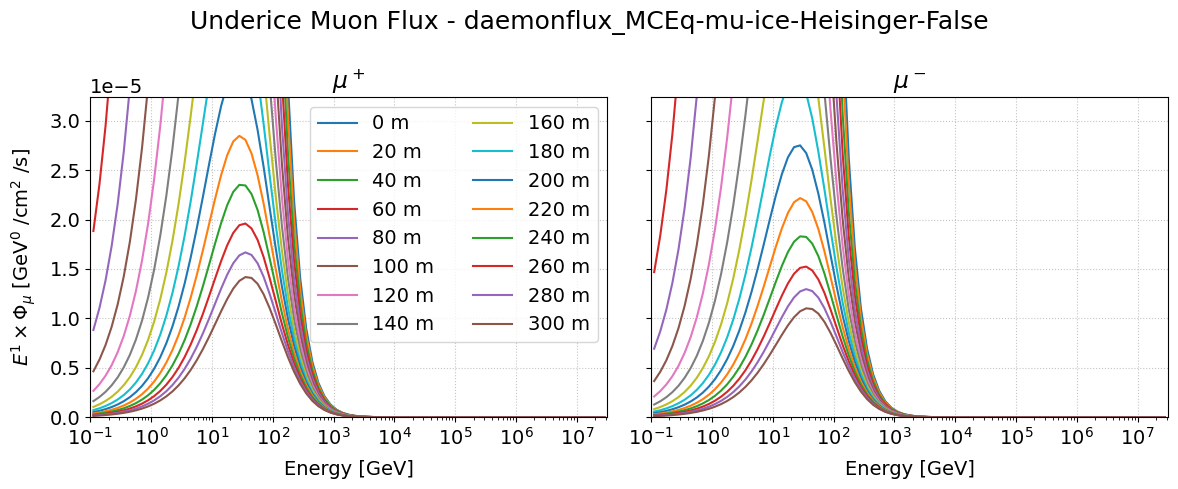

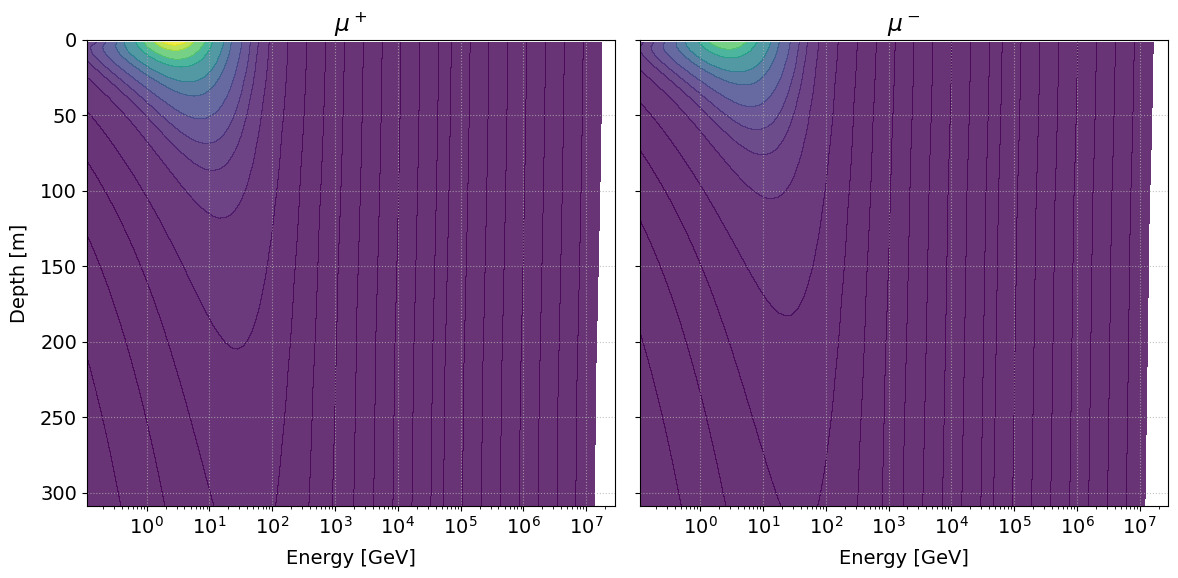

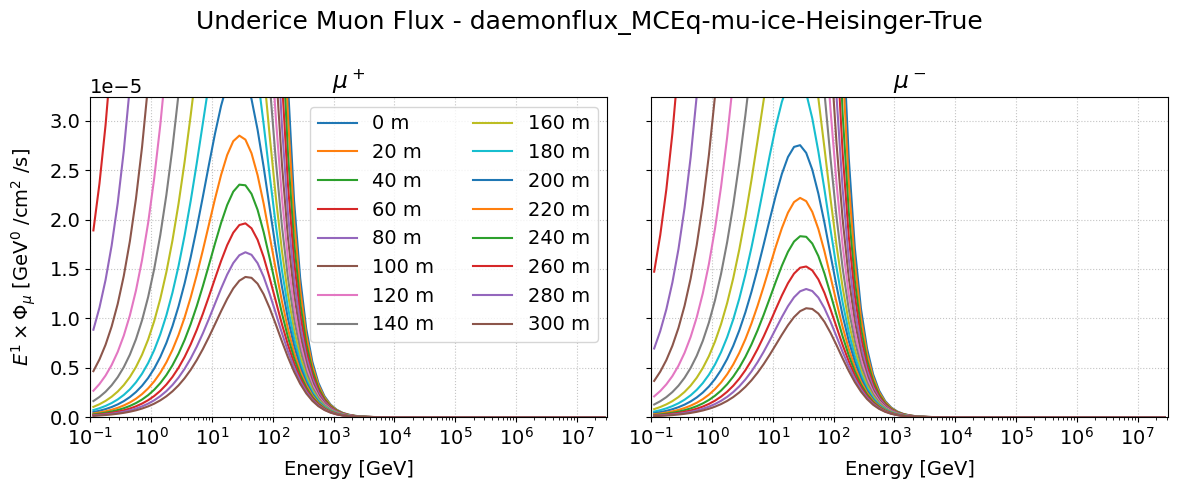

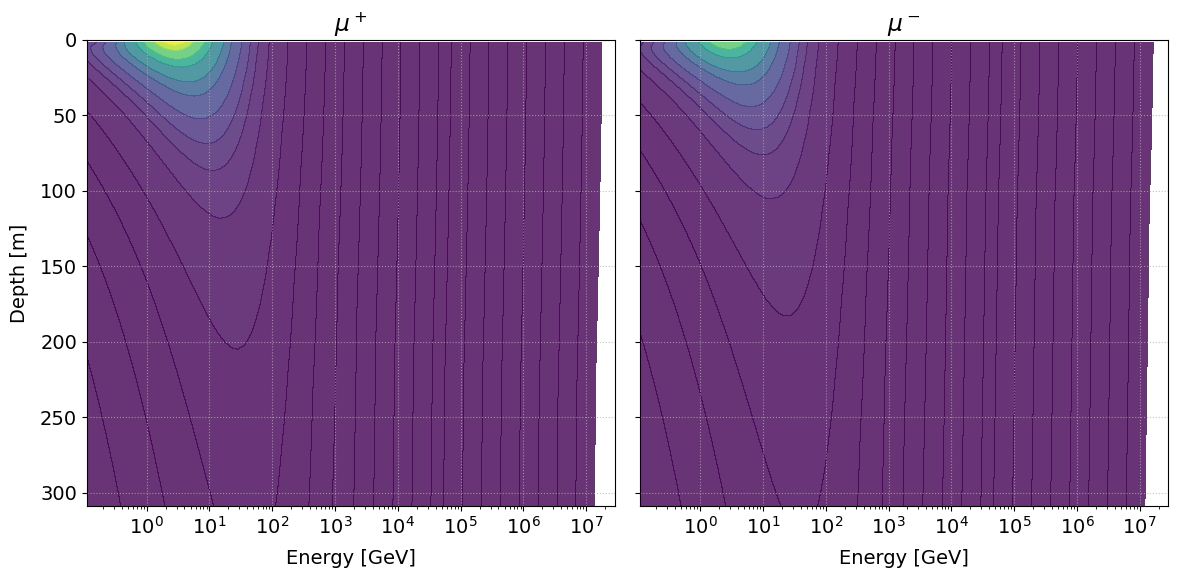

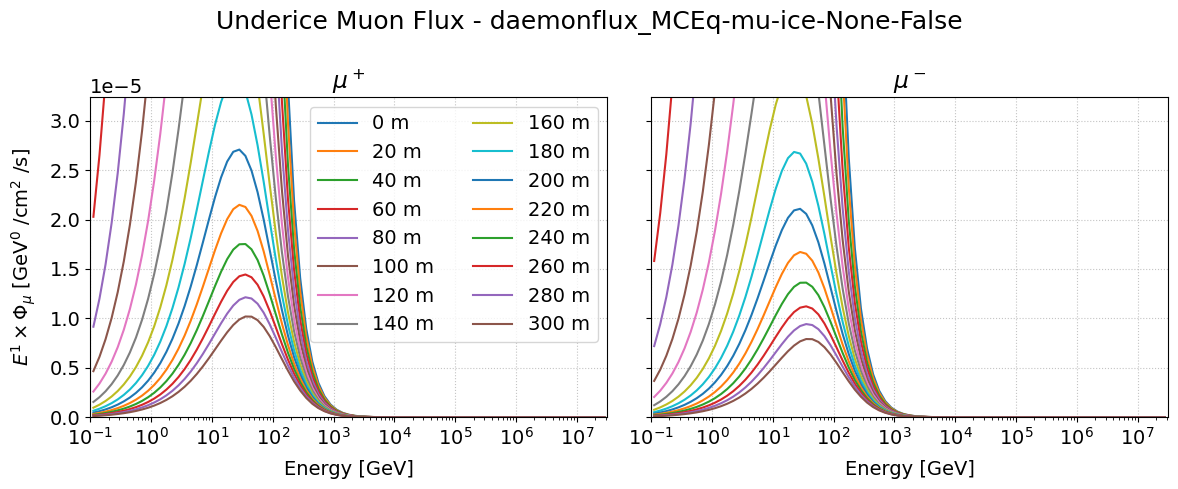

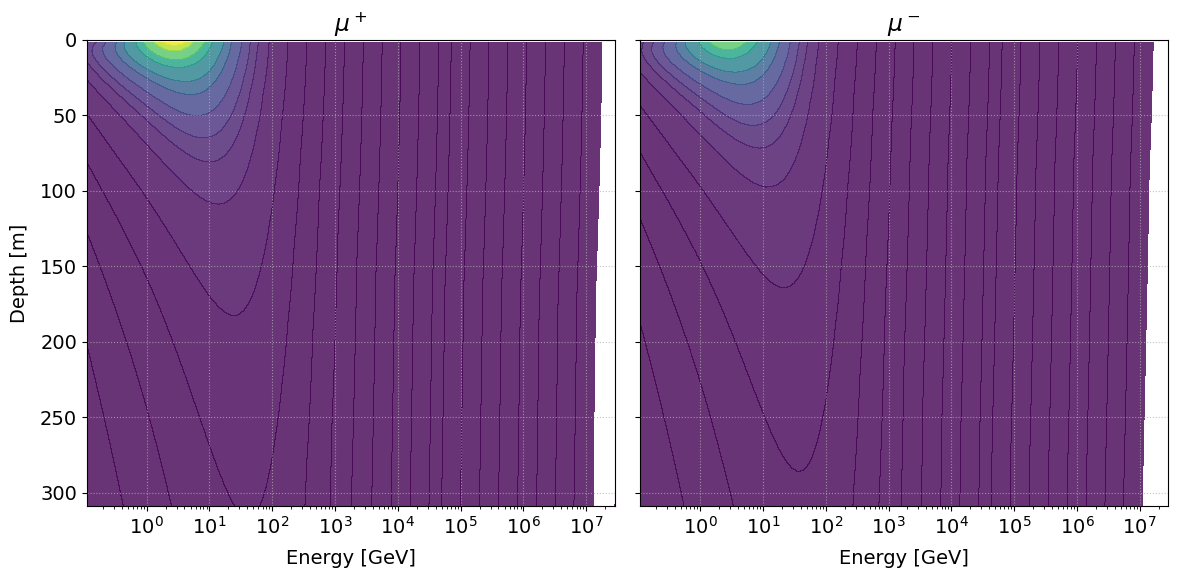

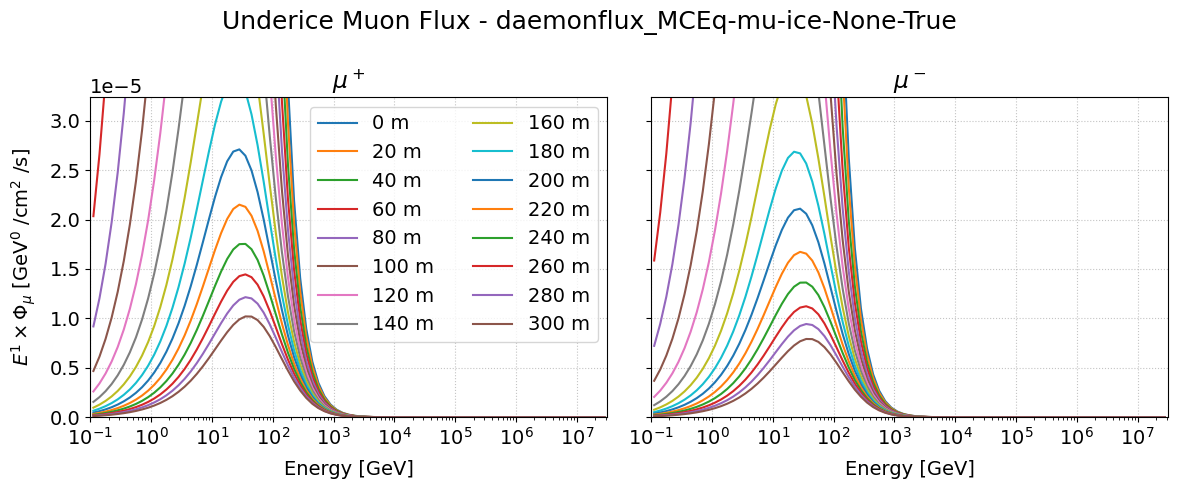

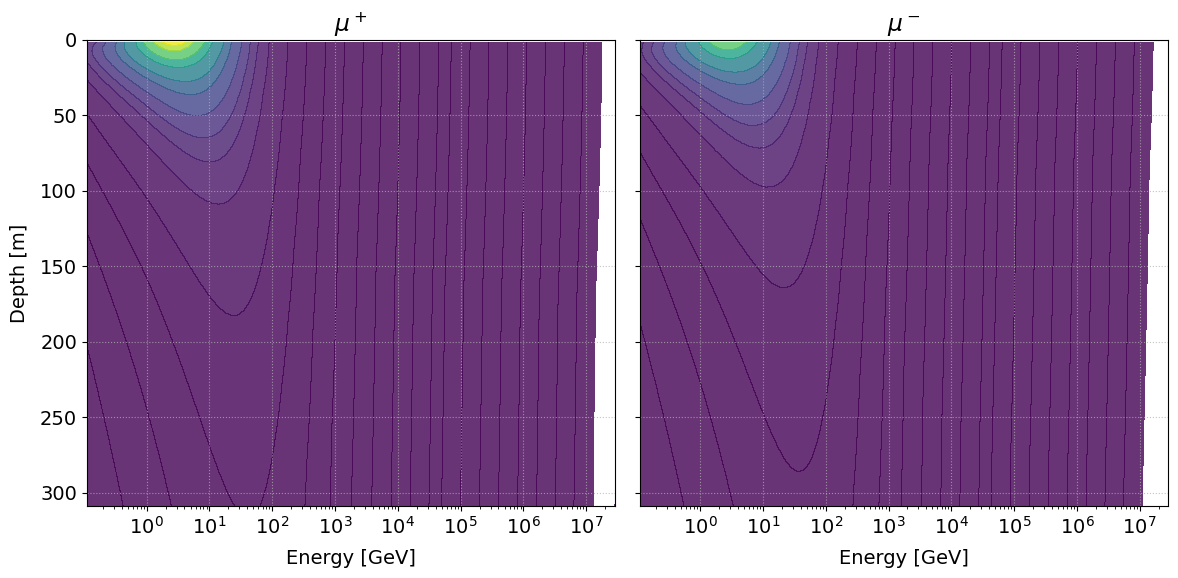

In [78]:
# Plot underice muon spectra

Epow = 1

Prop = Prop_DC

if len(Prop.Phi['ice'])>0 and len(Prop.Phi['ice'])<100:
    for j in range(len(Prop.Phi['ice'])):
        fig, (ax1,ax2) = plt.subplots(1,2, figsize=(12,5), tight_layout=True, sharex = True, sharey=True)
        for z in np.arange(Prop.z_bins[0],Prop.z_bins[-1],20.):
            i = np.argmin(abs(Prop.z_bins-z))
            ax1.plot(Prop.E_mu, Prop.Phi['ice'][j,0,:,i]*Prop.E_mu**Epow, label='{:.0f} m'.format(z))
            ax2.plot(Prop.E_mu, Prop.Phi['ice'][j,1,:,i]*Prop.E_mu**Epow)
        ax1.set(xlim = (Prop.E_mu_bins[0], Prop.E_mu_bins[-1]),
                xscale = 'log',
                xlabel = 'Energy [GeV]',
                title = r'$\mu^+$',
                ylim = (np.min(Prop.Phi['ice']*np.reshape(Prop.E_mu**Epow,(1,1,-1,1)))/100,
                        np.max(Prop.Phi['ice']*np.reshape(Prop.E_mu**Epow,(1,1,-1,1)))*1.05/100),
                #yscale = 'log',
                ylabel = r'$E^{} \times \Phi_\mu$ [GeV$^{}$ /cm$^2$ /s]'.format(Epow, Epow-1)
              )
        ax1.legend(ncols=2)
        ax2.set(xlim = (Prop.E_mu_bins[0], Prop.E_mu_bins[-1]),
                xscale = 'log',
                xlabel = 'Energy [GeV]',
                title = r'$\mu^-$',
              )
        plt.suptitle('Underice Muon Flux - {}'.format(Prop.model_names['ice'][j]), size=18)
        plt.show()

        fig, (ax1,ax2) = plt.subplots(1,2, figsize=(12,6), tight_layout=True, sharex=True, sharey=True)
        #ax1.pcolormesh(Prop.E_mu_bins, Prop.z_bins, Prop.Phi_ice[j,0,0,:,:-1].T*np.reshape(Prop.E_mu**Epow, (1,-1)),
                       #norm = mpl.colors.PowerNorm(gamma=0.2))
        #ax2.pcolormesh(Prop.E_mu_bins, Prop.z_bins, Prop.Phi_ice[j,0,1,:,:-1].T*np.reshape(Prop.E_mu**Epow, (1,-1)),
                       #norm = mpl.colors.PowerNorm(gamma=0.2))

        N_levels = 30
        levels = np.sort(Prop.Phi['ice'][j,0,:,0].T*np.reshape(Prop.E_mu**Epow, (-1)))[np.linspace(0,len(Prop.E_mu)-1,N_levels, dtype=int)][1:]
        #levels = np.linspace(np.min(Prop.Phi_ice[j,0,0,:,:-1].T*np.reshape(Prop.E_mu**Epow, (1,-1))), np.max(Prop.Phi_ice[j,0,0,:,:-1].T*np.reshape(Prop.E_mu**Epow, (1,-1))), N_levels)

        cf1 = ax1.contourf(Prop.E_mu, Prop.z, Prop.Phi['ice'][j,0,:,:-1].T*np.reshape(Prop.E_mu**Epow, (1,-1)),
                       levels=levels, alpha=0.8)
        cf2 = ax2.contourf(Prop.E_mu, Prop.z, Prop.Phi['ice'][j,1,:,:-1].T*np.reshape(Prop.E_mu**Epow, (1,-1)),
                       levels=levels, alpha=0.8)
        ax1.set(xscale = 'log',
                xlabel = 'Energy [GeV]',
                ylabel = 'Depth [m]',
                ylim = (Prop.z_bins[-1], Prop.z_bins[0]),
                title = r'$\mu^+$',
              )
        ax2.set(xscale = 'log',
                xlabel = 'Energy [GeV]',
                title = r'$\mu^-$',
              )
        plt.show()

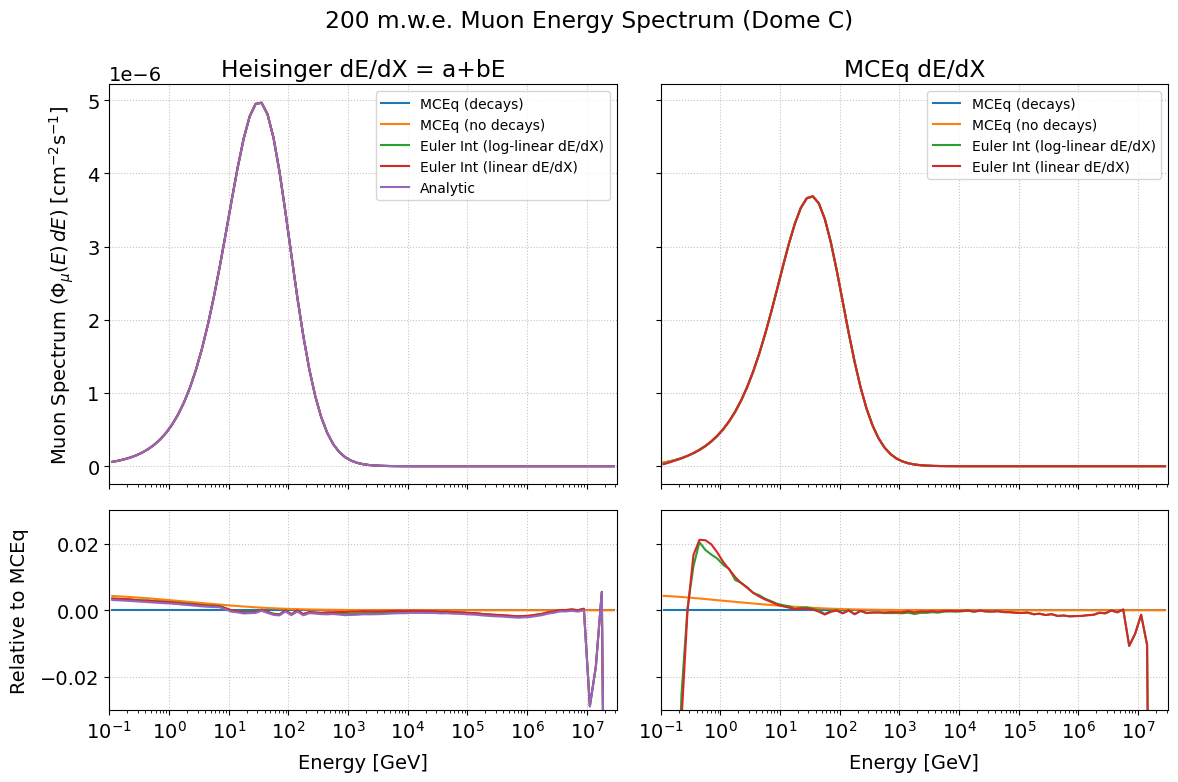

In [90]:
contloss_plots = True

Prop=Prop_DC

if contloss_plots:
    labels = ['Analytic', 'Euler Int (log-linear dE/dX)', 'Euler Int (linear dE/dX)', 'Euler Int (log-linear dE/dX)', 'Euler Int (linear dE/dX)', 'MCEq (decays)', 'MCEq (no decays)', 'MCEq (decays)', 'MCEq (no decays)']

    if len(Prop.Phi['ice'])>0:
        fig, axes = plt.subplots(2,2, figsize=(12,8), tight_layout=True, sharex = True, sharey='row', height_ratios=[2,1])
        h_i = 200
        for j in [5,6,1,2,0]:
            axes[0,0].plot(Prop.E_mu, Prop.Phi['ice'][j,0,:,h_i]*Prop.dE_mu, label=labels[j])
            axes[1,0].plot(Prop.E_mu, Prop.Phi['ice'][j,0,:,h_i]/Prop.Phi['ice'][5,0,:,h_i]-1, label=labels[j])
        for j in [7,8,3,4]:
            axes[0,1].plot(Prop.E_mu, Prop.Phi['ice'][j,0,:,h_i]*Prop.dE_mu, label=labels[j])
            axes[1,1].plot(Prop.E_mu, Prop.Phi['ice'][j,0,:,h_i]/Prop.Phi['ice'][7,0,:,h_i]-1, label=labels[j])
        axes[0,0].set(
            #xscale='log',
            #xlabel='Energy [GeV]',
            #yscale='log',
            ylabel=r'Muon Spectrum ($\Phi_\mu(E)\,dE$) [cm$^{-2}$s$^{-1}$]',
            title='Heisinger dE/dX = a+bE',
        )
        axes[1,0].set(
            xscale='log',
            xlim=(Prop_DC.E_mu_bins[0],Prop_DC.E_mu_bins[-1]),
            xlabel='Energy [GeV]',
            #yscale='log',
            ylim=(-0.03,0.03),
            ylabel='Relative to MCEq',
        )
        axes[0,1].set(
            title='MCEq dE/dX',
        )
        axes[1,1].set(
            xlabel='Energy [GeV]',
        )
        axes[0,0].legend(fontsize=10)
        axes[0,1].legend(fontsize=10)
        #axes[1,0].legend(fontsize=10)
        #axes[1,1].legend(fontsize=10)
        plt.suptitle('{:.0f} m.w.e. Muon Energy Spectrum (Dome C)'.format(Prop.h_bins[h_i]))
        plt.show()

In [115]:
# Plot underice muon spectra

if len(Prop.Phi['ice'])>0:
    fig, (ax1,ax2) = plt.subplots(1,2, figsize=(12,5), tight_layout=True, sharex = True, sharey=True)
    for i,p in enumerate(Prop.Phi['ice']):
        ax1.plot(Prop.z_bins, np.sum(p[0]*Prop.dE_mu.reshape((-1,1)), axis=0), alpha=0.5)
        ax2.plot(Prop.z_bins, np.sum(p[1]*Prop.dE_mu.reshape((-1,1)), axis=0), alpha=0.5)
    ax1.plot(Prop.z_bins, np.sum(np.mean(Prop.Phi['ice'][:,0], axis=0)*Prop.dE_mu.reshape((-1,1)), axis=0), c='k', ls='--')
    ax2.plot(Prop.z_bins, np.sum(np.mean(Prop.Phi['ice'][:,1], axis=0)*Prop.dE_mu.reshape((-1,1)), axis=0), c='k', ls='--')
    ax1.set(#xlim = (Prop.E_mu_bins[0], Prop.E_mu_bins[-1]),
            #xscale = 'log',
            #xlabel = 'Energy [GeV]',
            title = r'$\mu^+$',
            #ylim = (np.min(Prop.Phi['ice']*np.reshape(Prop.E_mu**Epow,(1,1,-1,1))),
                    #np.max(Prop.Phi['ice']*np.reshape(Prop.E_mu**Epow,(1,1,-1,1)))*1.05),
            yscale = 'log',
            ylabel = r'$E^{} \times \Phi_\mu$ [GeV$^{}$ /cm$^2$ /s]'.format(Epow, Epow-1)
          )
    #ax1.legend(ncols=2)
    ax2.set(#xlim = (Prop.E_mu_bins[0], Prop.E_mu_bins[-1]),
            #xscale = 'log',
            #xlabel = 'Energy [GeV]',
            title = r'$\mu^-$',
          )
    #plt.suptitle('Underice Muon Flux - {}'.format(Prop.model_names['ice'][j]), size=18)
    plt.show()

### Production Rates

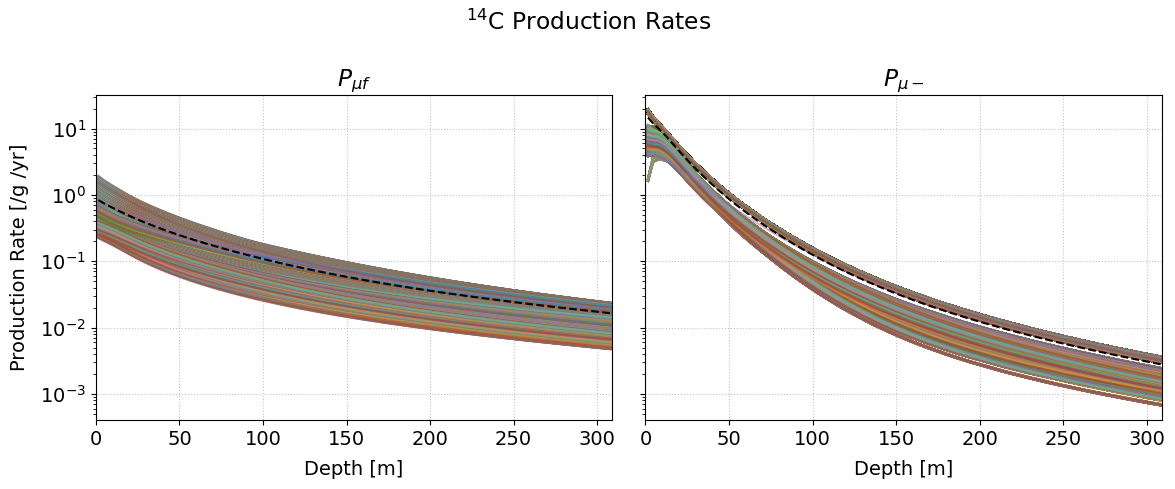

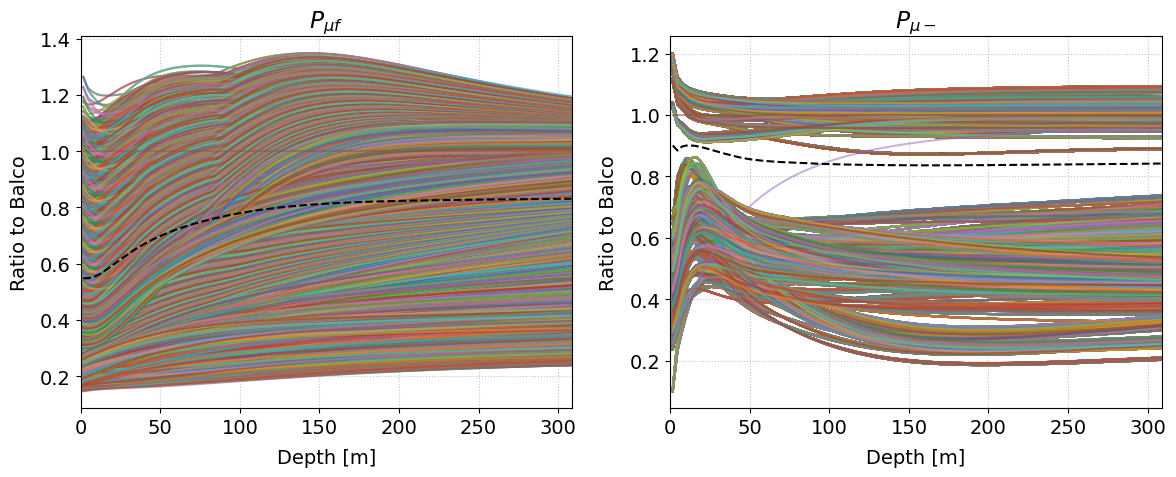

In [116]:
# Plot 14C Production rates

Prop=Prop_DC

if len(Prop.Phi['prod'])>0:
    fig, (ax1, ax2) = plt.subplots(1,2, figsize=(12,5), tight_layout=True, sharex = True, sharey=True)
    for i,p in enumerate(Prop.Phi['prod']):
        ax1.plot(Prop.z, p[0], label=Prop.model_names['prod'][i], alpha=0.5)
        ax2.plot(Prop.z, p[1], alpha=0.5)
    ax1.plot(Prop.z, np.mean(Prop.Phi['prod'][:,0], axis=0), c='k', ls='--')
    ax2.plot(Prop.z, np.mean(Prop.Phi['prod'][:,1], axis=0), c='k', ls='--')
    ax1.set(xlim = (Prop.z_bins[0], Prop.z_bins[-1]),
            xlabel = 'Depth [m]',
            title = r'$P_{\mu f}$',
            yscale = 'log',
            ylabel = r'Production Rate [/g /yr]'
          )
    #ax1.legend(fontsize=10, ncols=2)
    ax2.set(xlim = (Prop.z_bins[0], Prop.z_bins[-1]),
            #xlim = (Prop.z[0], Prop.z_bins[-1]),
            #xscale='log',
            xlabel = 'Depth [m]',
            title = r'$P_{\mu-}$',
            #yscale = 'log',
            #ylabel = r'Production Rate [/g /yr]'
          )
    plt.suptitle(r'$^{14}$C Production Rates')
    plt.show()

    fig, (ax1, ax2) = plt.subplots(1,2, figsize=(12,5), tight_layout=True, sharex = True)
    for i,p in enumerate(Prop.Phi['prod']):
        ax1.plot(Prop.z, p[0]/Prop.Phi['prod'][-1,0], alpha=0.5)#, label=Prop.model_names['prod'][i])
        ax2.plot(Prop.z, p[1]/Prop.Phi['prod'][-1,1], alpha=0.5)
    ax1.plot(Prop.z, np.mean(Prop.Phi['prod'][:,0], axis=0)/Prop.Phi['prod'][-1,0], c='k', ls='--')
    ax2.plot(Prop.z, np.mean(Prop.Phi['prod'][:,1], axis=0)/Prop.Phi['prod'][-1,1], c='k', ls='--')
    ax1.set(xlim = (Prop.z_bins[0], Prop.z_bins[-1]),
            xlabel = 'Depth [m]',
            title = r'$P_{\mu f}$',
            ylabel='Ratio to {}'.format(Prop.model_names['prod'][-1]),
          )
    #ax1.legend(fontsize=10, ncols=2)
    ax2.set(xlim = (Prop.z_bins[0], Prop.z_bins[-1]),
            xlabel = 'Depth [m]',
            title = r'$P_{\mu-}$',
            #yscale = 'log',
            #ylabel = r'Production Rate [/g /yr]'
            ylabel='Ratio to {}'.format(Prop.model_names['prod'][-1]),
          )
    plt.show()

## Organize Production Model Instances

In [19]:
N_alphas = len(alphas)
N_contloss = 2 # number of continous energy loss models
N_fluxfit = 3 # number of fits to total flux (+1 for no fit)
N_atmFit = 2 # number of atmospheric muon spectrum fits
N_atm = 2 # number of atmospheric profiles
N_int = 11 # number of interaction models
N_primary = 12 # number of primary models
N_H = 2 # number of pure Heisinger models

In [20]:
models_MCEq = np.reshape(model_names[:-N_H], (N_alphas,N_contloss*N_fluxfit,-1))[:,:N_contloss,N_atmFit:].reshape((N_alphas,N_contloss,N_atm,N_int,-1))
#axis0 - alpha
#axis1 - Underice Propagation Model
#axis2 - Month (Atmospheric Profile)
#axis3 - Interaction Model
#axis4 - Primary Model

P_MCEq = P_14C[:-N_H].reshape((N_alphas,N_contloss*N_fluxfit,-1,*P_14C.shape[1:]))[:,:N_contloss,N_atmFit:].reshape((N_alphas,N_contloss,N_atm,N_int,-1,*P_14C.shape[1:]))
#axis0 - alpha
#axis1 - Underice Propagation Model
#axis2 - Month (Atmospheric Profile)
#axis3 - Interaction Model
#axis4 - Primary Model
#axis5 - Production Mode
#axis6 - Production Depth
P_MCEq.shape

(34, 2, 2, 11, 12, 2, 1254)

In [21]:
models_AtmFit = np.reshape(model_names[:-N_H], (N_alphas,N_contloss*N_fluxfit,-1))[:,:N_contloss,:N_atmFit]
#axis0 - alpha
#axis1 - Underice Propagation Model
#axis2 - Atmospheric Muon Flux Fit

P_AtmFit = P_14C[:-N_H].reshape((N_alphas,N_contloss*N_fluxfit,-1,*P_14C.shape[1:]))[:,:N_contloss,:N_atmFit]
#axis0 - alpha
#axis1 - Underice Propagation Model
#axis2 - Atmospheric Muon Flux Fit
#axis3 - Production Mode
#axis4 - Depth
P_AtmFit.shape

(34, 2, 2, 2, 1254)

In [22]:
models_FluxFit = np.reshape(model_names[:-N_H], (N_alphas,N_contloss*N_fluxfit,-1))[:,N_contloss:]
#axis0 - alpha
#axis1 - Underice Propagation Model
#axis2 - AtmFit / MCEq Model

P_FluxFit = P_14C[:-N_H].reshape((N_alphas,N_contloss*N_fluxfit,-1,*P_14C.shape[1:]))[:,N_contloss:]
#axis0 - alpha
#axis1 - Underice Propagation Model
#axis2 - AtmFit / MCEq Model
#axis3 - Production Mode
#axis4 - Depth
P_FluxFit.shape

(34, 4, 266, 2, 1254)

In [23]:
models_Heisinger = np.array(model_names[-N_H:])

P_Heisinger = P_14C[-N_H:]
#axis0 - Heisinger Model
#axis1 - Production Mode
#axis2 - Depth
P_Heisinger.shape

(2, 2, 1254)

## Priors on Production Model Instances

In [24]:
# weights on MCEq models
alpha = np.array([0.75, 0.93])
dalpha = np.array([0.08, 0.07])

w_alpha = np.array([0.5,0.5]) # alpha
w_alphas = np.sum([np.exp(-((alphas-a)/dalpha[i])**2/2)/dalpha[i] * w_alpha[i] for i,a in enumerate(alpha)], axis=0)

w_ice = np.ones(models_MCEq.shape[1]) # ice propagation model
#w_ice[5:] = 0.

w_atm = np.ones(models_MCEq.shape[2]) # atmospheric profile

w_int = np.ones(models_MCEq.shape[3]) # interaction model
#w_int[:1] = 0.

w_primary = np.ones(models_MCEq.shape[4]) # primary model
#w_primary[3:] = 0.

w_MCEq = w_alphas.reshape((-1,1,1,1,1)) * w_ice.reshape((1,-1,1,1,1)) * w_atm.reshape((1,1,-1,1,1)) * w_int.reshape((1,1,1,-1,1)) * w_primary.reshape((1,1,1,1,-1))
w_MCEq /= np.sum(w_MCEq) # normalize the weights

In [25]:
w_surf = np.ones(models_AtmFit.shape[2])

w_AtmFit = w_alphas.reshape((-1,1,1)) * w_ice.reshape((1,-1,1)) * w_surf.reshape((1,1,-1))
w_AtmFit /= np.sum(w_AtmFit)

In [26]:
w_FluxFit = np.repeat(np.concatenate((w_AtmFit, w_MCEq.reshape((*w_MCEq.shape[:2],-1))), axis=-1), N_fluxfit-1, axis=1)
w_FluxFit /= np.sum(w_FluxFit)

## Production Model Fits

In [27]:
production_models = ['MCEq', 'AtmFit', 'FluxFit']
PM_labels = ['{}-{:.2f}'.format(m,a) for m in production_models for a in alpha]
PM_labels

['MCEq-0.75',
 'MCEq-0.93',
 'AtmFit-0.75',
 'AtmFit-0.93',
 'FluxFit-0.75',
 'FluxFit-0.93']

In [28]:
def get_P_alpha_cov(P, w, alphas, a, da):
    P_a = P[np.isclose(alphas, a)][0].reshape((-1,*P.shape[-2:]))
    w_a = w[np.isclose(alphas, a)][0].reshape((-1))
    w_a /= np.sum(w_a)
    Sigma_a = np.cov(P_a.reshape(len(P_a),-1), aweights=w_a, rowvar=False).reshape(*P_a.shape[1:],*P_a.shape[1:]).swapaxes(1,2)
    alpha_cut = (alphas<=(a+da)) * (alphas>=(a-da)) * ~np.isclose(alphas, a)
    P_range = P[alpha_cut].reshape((np.sum(alpha_cut),-1,*P.shape[-2:]))
    dP_da = np.average((P_range - P_a)/(alphas[alpha_cut]-a).reshape((-1,1,1,1)), weights=np.exp(-((alphas[alpha_cut]-a)/da)**2/2), axis=0)
    #dSigma_a = np.average(dP_da.reshape((len(w_a),-1,1)) * dP_da.reshape((len(w_a),1,-1)), weights=w_a, axis=0).reshape(*P_a.shape[1:],*P_a.shape[1:]).swapaxes(1,2)
    dSigma_a = np.einsum('aik,ajl,a->ijkl', dP_da, dP_da, w_a, optimize=True)
    
    #P_a_avg = np.average(P_a, weights=w_a, axis=0)
    P_a_cov = Sigma_a + dSigma_a * da**2
    #P_a_std = np.sqrt([np.diag(P_a_cov[0,0]), np.diag(P_a_cov[1,1])])
    
    return P_a_cov

In [29]:
alpha_i = [8,-8] # indexes of central alphas
P_avg = np.array([np.average(P[i].reshape((-1,*P.shape[-2:])), weights=w[i].reshape((-1)), axis=0) for P,w in zip([P_MCEq,P_AtmFit,P_FluxFit],[w_MCEq, w_AtmFit, w_FluxFit]) for i in alpha_i])
#axis0 - Production ModelSet
#axis1 - Production Mode
#axis2 - Production Depth
P_avg.shape

(6, 2, 1254)

In [30]:
P_cov = np.array([get_P_alpha_cov(P, w, alphas, a, da) for P,w in zip([P_MCEq,P_AtmFit,P_FluxFit],[w_MCEq, w_AtmFit, w_FluxFit]) for a,da in zip(alpha,dalpha)])
#axis0 - Production ModelSet
#axis1 - Production Mode
#axis2 - Production Mode
#axis3 - Production Depth
#axis4 - Production Depth
P_cov.shape

(6, 2, 2, 1254, 1254)

/tmp/ipykernel_1907/33425054.py:9: RuntimeWarning: invalid value encountered in sqrt
  P_plot_std = np.sqrt(P_cov[:,:,:,np.arange(len(h)),np.arange(len(h))])


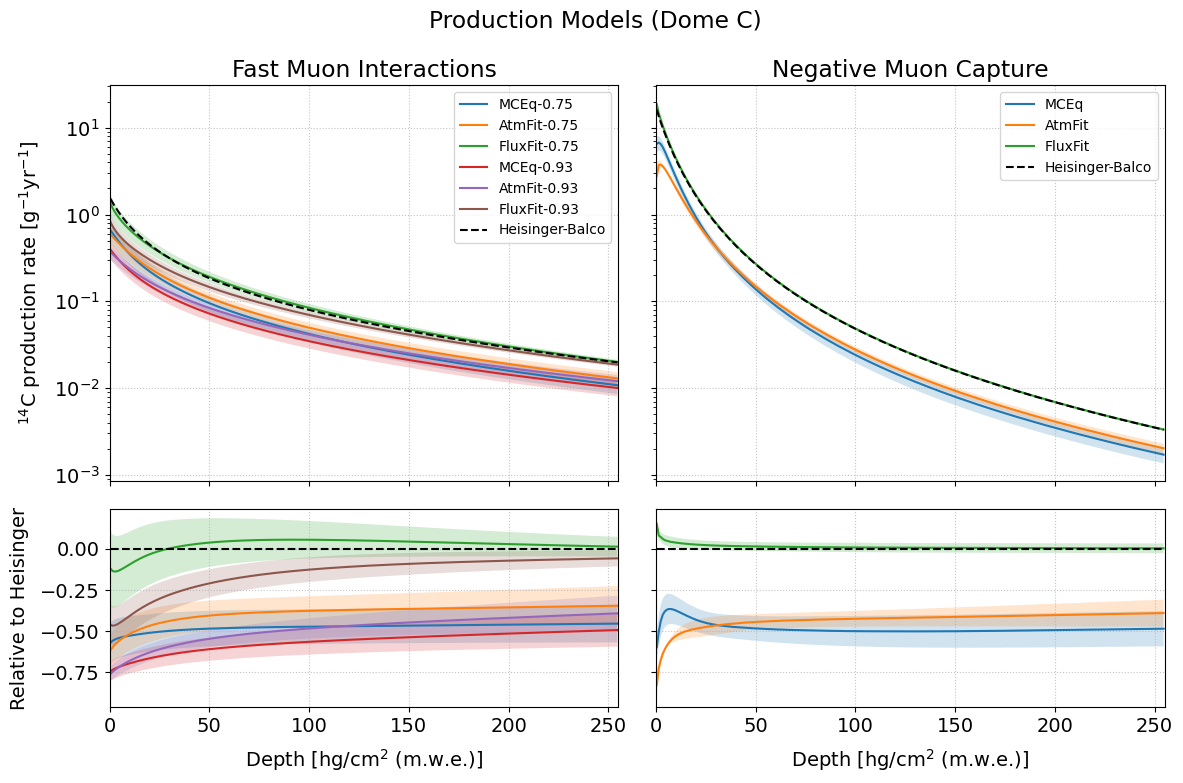

In [31]:
# Plot Production Rates w/ Depth
fig, axes = plt.subplots(2,2, figsize=(12,8), tight_layout=True, sharex = True, sharey='row', height_ratios=[2,1])

Prop = Prop_DC
h = Prop.h

P_plot = P_avg[:,:,:len(h)]
P_plot = P_plot.reshape((3,2,*P_plot.shape[1:])).swapaxes(0,1).reshape(P_plot.shape)
P_plot_std = np.sqrt(P_cov[:,:,:,np.arange(len(h)),np.arange(len(h))])
P_plot_std = P_plot_std.reshape((3,2,*P_plot_std.shape[1:])).swapaxes(0,1).reshape(P_plot_std.shape)

for i in range(2): # fast, neg
    pH = P_Heisinger[-1,i,:len(h)]
    for j in range(2): # true values, relative
        rel = pH if j==1 else 1.
        
        P_cut = P_plot[:,i] if i==0 else P_plot[:3,i]
        P_std = P_plot_std[:,i,i] if i==0 else P_plot_std[:3,i,i]
        labels = ['{}-{:.2f}'.format(m,a) for a in alpha for m in production_models] if i==0 else production_models
        
        for p,dp,l in zip(P_cut, P_std, labels):
            axes[j,i].fill_between(h, (p-dp)/rel-j, (p+dp)/rel-j, alpha=0.2)
            axes[j,i].plot(h, p/rel-j, label=l)
        axes[j,i].plot(h, pH/rel-j, ls='--', c='k', label='Heisinger-Balco')
        #axes[j,i].plot(h, P_Heisinger[0,i,:len(h)]/rel-j, ls='--', c='k', label='Heisinger')
        if j==0:
            axes[j,i].legend(fontsize=10)
axes[0,0].set(
    title='Fast Muon Interactions',
    xlim=(Prop.h_bins[0],Prop.h_bins[-1]),
    ylabel=r'$^{14}$C production rate [g$^{-1}$yr$^{-1}$]',
    yscale='log',
)
axes[0,1].set(
    title='Negative Muon Capture',
)
axes[1,0].set(
    ylabel='Relative to Heisinger',
    xlabel=r'Depth [hg/cm$^2$ (m.w.e.)]',
)
axes[1,1].set(
    xlabel=r'Depth [hg/cm$^2$ (m.w.e.)]',
)
fig.suptitle('Production Models (Dome C)')
plt.show()

## Underground Spectrum Models

In [34]:
Ice = np.concatenate((Prop_DC.Phi['ice'], Prop_TG.Phi['ice']), axis=-1)

In [265]:
Ice_MCEq = Ice.reshape((N_contloss*N_fluxfit,-1,*Ice.shape[1:]))[:N_contloss,N_atmFit:].reshape((N_contloss,N_atm,N_int,-1,*Ice.shape[1:]))
#axis0 - Underice Propagation Model
#axis1 - Month (Atmospheric Profile)
#axis2 - Interaction Model
#axis3 - Primary Model
#axis4 - Charge
#axis5 - Energy
#axis6 - Production Depth
Ice_MCEq.shape

(2, 2, 11, 12, 2, 85, 1256)

In [266]:
Ice_AtmFit = Ice.reshape((N_contloss*N_fluxfit,-1,*Ice.shape[1:]))[:N_contloss,:N_atmFit]
#axis0 - Underice Propagation Model
#axis1 - Atmospheric Muon Flux Fit
#axis2 - Charge
#axis3 - Energy
#axis4 - Depth
Ice_AtmFit.shape

(2, 2, 2, 85, 1256)

In [267]:
Ice_FluxFit = Ice.reshape((N_contloss*N_fluxfit,-1,*Ice.shape[1:]))[N_contloss:]
#axis0 - Underice Propagation Model
#axis1 - AtmFit / MCEq Model
#axis2 - Charge
#axis3 - Energy
#axis4 - Depth
Ice_FluxFit.shape

(4, 266, 2, 85, 1256)

In [268]:
w_MCEq_ice = np.sum(w_MCEq, axis=0)
w_MCEq_ice /= np.sum(w_MCEq_ice) # normalize the weights

w_AtmFit_ice = np.sum(w_AtmFit, axis=0)
w_AtmFit_ice /= np.sum(w_AtmFit_ice)

w_FluxFit_ice = np.sum(w_FluxFit, axis=0)
w_FluxFit_ice /= np.sum(w_FluxFit_ice)

In [269]:
Ice_avg = np.array([np.average(I.reshape((-1,*Ice.shape[-3:])), weights=w.reshape((-1)), axis=0) for I,w in zip([Ice_MCEq,Ice_AtmFit,Ice_FluxFit],[w_MCEq_ice, w_AtmFit_ice, w_FluxFit_ice])])
#axis0 - Production ModelSet
#axis1 - Charge
#axis2 - Energy
#axis3 - Depth
Ice_avg.shape

(3, 2, 85, 1256)

In [270]:
def average(x, w, ax=-1, keepdims=False):
    return np.sum(x*w, axis=ax, keepdims=keepdims)/np.sum(w, axis=ax, keepdims=keepdims)

In [271]:
def std(x, w, ax):
    return np.sqrt(average((x-average(x, w, ax, keepdims=True))**2, w, ax))

In [272]:
std(Prop.E_mu.reshape((1,1,-1,1)), Ice_avg*Prop.dE_mu.reshape((1,1,-1,1)), -2).shape

(3, 2, 1256)

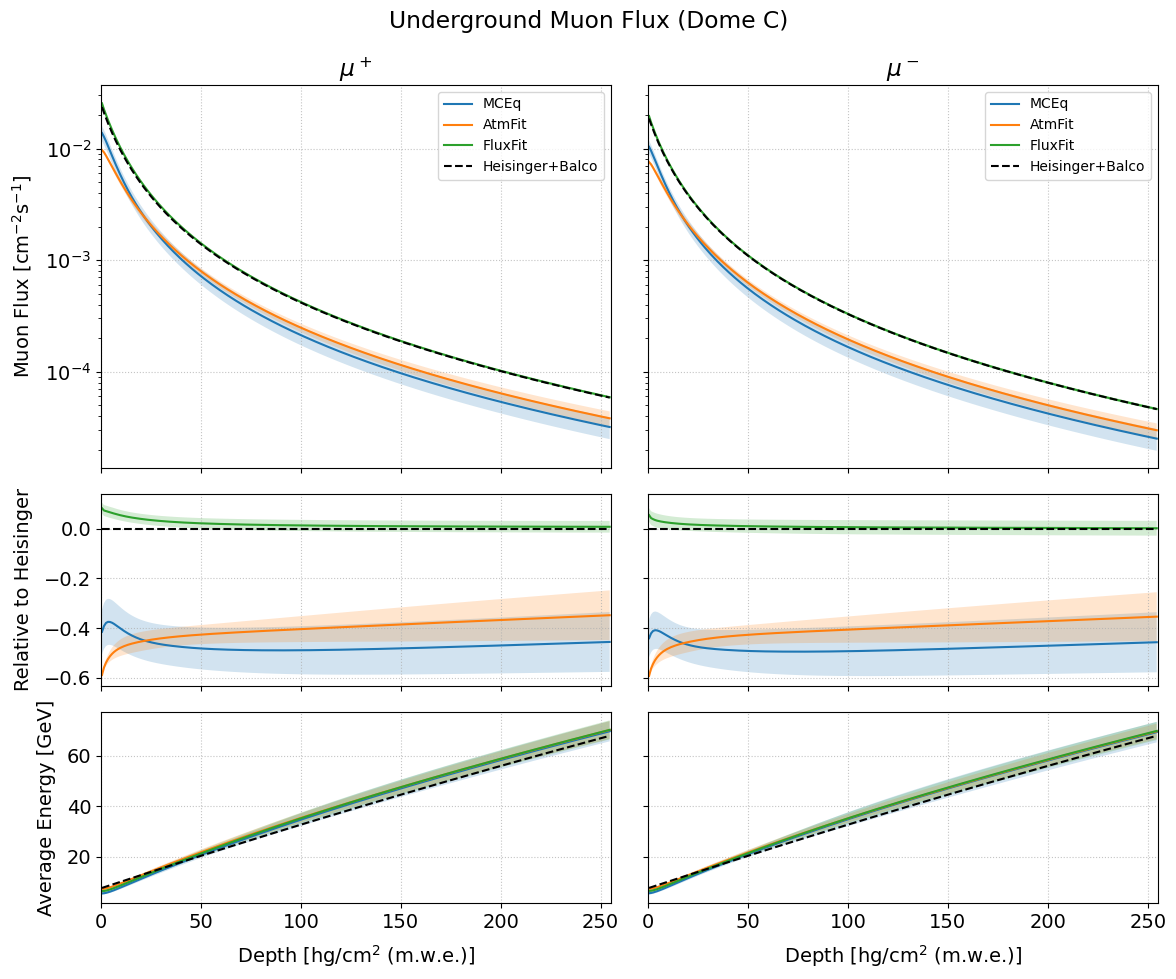

In [285]:
# Plot total flux & average energy w/ depth + standard deviations
fig, axes = plt.subplots(3,2, figsize=(12,10), tight_layout=True, sharex = True, sharey='row', height_ratios=[2,1,1])

Prop = Prop_DC
h = Prop.h

Ice_cut = Prop.dE_mu @ Ice_avg[:,:,:,:len(h)]
Ice_std = np.array([std(Prop.dE_mu@I, w.reshape((*w.shape, 1,1)), ax) for I,w,ax in zip([Ice_MCEq, Ice_AtmFit, Ice_FluxFit], [w_MCEq_ice, w_AtmFit_ice, w_FluxFit_ice], [(0,1,2,3),(0,1),(0,1)])])[:,:,:len(h)] # standard deviations of total muon flux
H_ice = F.phi_all(h,Prop.dh,Prop.H)[0]

# mean energy of average spectrum
Ice_E = ((Prop.E_mu*Prop.dE_mu)@Ice_avg[:,:,:,:len(h)])/(Prop.dE_mu @ Ice_avg[:,:,:,:len(h)])
#standard deviations of average muon energy
Ice_dE = np.array([std(((Prop.E_mu*Prop.dE_mu)@I)/(Prop.dE_mu@I), w.reshape((*w.shape,1,1)), ax) for I,w,ax in zip([Ice_MCEq, Ice_AtmFit, Ice_FluxFit], [w_MCEq_ice, w_AtmFit_ice, w_FluxFit_ice], [(0,1,2,3),(0,1),(0,1)])])[:,:,:len(h)]
# average of muon energy standard deviations
#Ice_dE = np.array([np.average(std(Prop.E_mu, I*Prop.dE_mu.reshape((*([1]*len(ax)),1,-1,1)), -2), weights=w, axis=ax) for I,w,ax in zip([Ice_MCEq, Ice_AtmFit, Ice_FluxFit], [w_MCEq_ice, w_AtmFit_ice, w_FluxFit_ice], [(0,1,2,3),(0,1),(0,1)])
#standard deviation of average spectrum
#Ice_dE = np.exp(std(np.log(Prop.E_mu).reshape((1,1,-1,1)), Ice_avg*Prop.dE_mu.reshape((1,1,-1,1)), -2)[:,:,:len(h)])
H_E = F.Heisinger(h)[0]

for i in range(2): # pos, neg
    H = H_ice * (F.f_mu_neg() if i==1 else 1-F.f_mu_neg())
    for j in range(3): # true values, relative, energies
        if j<2:
            rel = H if j==1 else 1.

            for I,dI,l in zip(Ice_cut[:,i], Ice_std[:,i], production_models):
                axes[j,i].fill_between(h, (I-dI)/rel-j, (I+dI)/rel-j, alpha=0.2)
                axes[j,i].plot(h, I/rel-j, label=l)
            axes[j,i].plot(h, H/rel-j, ls='--', c='k', label='Heisinger+Balco')
            if j==0:
                axes[j,i].legend(fontsize=10)
        else:
            for I,dI,l in zip(Ice_E[:,i], Ice_dE[:,i], production_models):
                axes[j,i].fill_between(h, I-dI, I+dI, alpha=0.2)
                axes[j,i].plot(h, I, label=l)
            axes[j,i].plot(h, H_E, ls='--', c='k', label='Heisinger')
axes[0,0].set(
    title=r'$\mu^+$',
    xlim=(Prop.h_bins[0],Prop.h_bins[-1]),
    ylabel=r'Muon Flux [cm$^{-2}$s$^{-1}$]',
    yscale='log',
)
axes[0,1].set(
    title=r'$\mu^-$',
)
axes[1,0].set(
    ylabel='Relative to Heisinger',
)
axes[1,1].set(
    
)
axes[2,0].set(
    xlabel=r'Depth [hg/cm$^2$ (m.w.e.)]',
    #yscale='log',
    ylabel='Average Energy [GeV]',
)
axes[2,1].set(
    xlabel=r'Depth [hg/cm$^2$ (m.w.e.)]',
)
fig.suptitle('Underground Muon Flux (Dome C)')
plt.show()

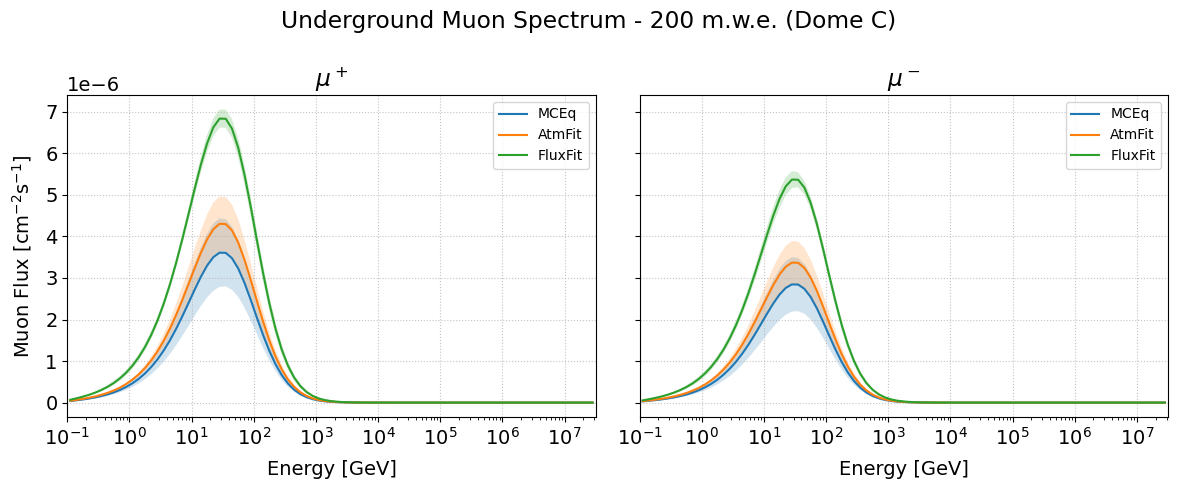

In [138]:
# Plot muon spectrum @ depth + deviations
fig, axes = plt.subplots(1,2, figsize=(12,5), tight_layout=True, sharex = True, sharey='row')

Prop = Prop_DC
E = Prop.E_mu

h = 200
h_i = np.argmin(abs(Prop.h-h))

Ice_cut = Ice_avg[:,:,:,h_i]*Prop.dE_mu.reshape((1,1,-1))
# standard deviations of total muon flux
Ice_std = np.array([std(I*Prop.dE_mu.reshape((*([1]*len(ax)),1,-1,1)), w.reshape((*w.shape,1,1,1)), ax) for I,w,ax in zip([Ice_MCEq, Ice_AtmFit, Ice_FluxFit], [w_MCEq_ice, w_AtmFit_ice, w_FluxFit_ice], [(0,1,2,3),(0,1),(0,1)])])[:,:,:,h_i]
H_E = F.Heisinger(h)[0]

for i in range(2): # pos, neg
    for I,dI,l in zip(Ice_cut[:,i], Ice_std[:,i], production_models):
        axes[i].fill_between(E, I-dI, I+dI, alpha=0.2)
        axes[i].plot(E, I, label=l)
    #axes[i].axvline(H_E, ls='--', c='k', label='Heisinger')
    axes[i].legend(fontsize=10)
axes[0].set(
    title=r'$\mu^+$',
    xlim=(Prop.E_mu_bins[0],Prop.E_mu_bins[-1]),
    xlabel='Energy [GeV]',
    xscale='log',
    ylabel=r'Muon Flux [cm$^{-2}$s$^{-1}$]',
    #yscale='log',
)
axes[1].set(
    title=r'$\mu^-$',
    xlabel='Energy [GeV]',
)
fig.suptitle('Underground Muon Spectrum - {:.0f} m.w.e. (Dome C)'.format(Prop.h[h_i]))
plt.show()

## Atmospheric Spectrum Models

In [76]:
Atm = np.array([Prop_DC.Phi['atm'], Prop_TG.Phi['atm']])

In [80]:
Atm.shape

(2, 266, 10, 2, 85)

In [87]:
Atm_MCEq = np.moveaxis(Atm[:,N_atmFit:].reshape((2,N_atm,N_int,-1,*Atm.shape[2:])), 0, -4)
#axis0 - Month (Atmospheric Profile)
#axis1 - Interaction Model
#axis2 - Primary Model
#axis3 - Site [Dome C, Taylor Glacier]
#axis4 - Zenith Angle
#axis5 - Charge
#axis6 - Energy
Atm_MCEq.shape

(2, 11, 12, 2, 10, 2, 85)

In [88]:
Atm_AtmFit = np.moveaxis(Atm[:,:N_atmFit], 0, -4)
#axis0 - Atmospheric Muon Flux Fit
#axis1 - Site [Dome C, Taylor Glacier]
#axis2 - Zenith Angle
#axis3 - Charge
#axis4 - Energy
Atm_AtmFit.shape

(2, 2, 10, 2, 85)

In [83]:
w_MCEq_atm = np.sum(w_MCEq, axis=(0,1))
w_MCEq_atm /= np.sum(w_MCEq_atm) # normalize the weights

w_AtmFit_atm = np.sum(w_AtmFit, axis=(0,1))
w_AtmFit_atm /= np.sum(w_AtmFit_atm)

In [90]:
Atm_avg = np.array([np.average(A.reshape((-1,*A.shape[-4:])), weights=w.reshape((-1)), axis=0) for A,w in zip([Atm_MCEq,Atm_AtmFit],[w_MCEq_atm, w_AtmFit_atm])])
#axis0 - Production ModelSet
#axis1 - Site
#axis2 - Zenith Angle
#axis3 - Charge
#axis4 - Energy
Atm_avg.shape

(2, 2, 10, 2, 85)

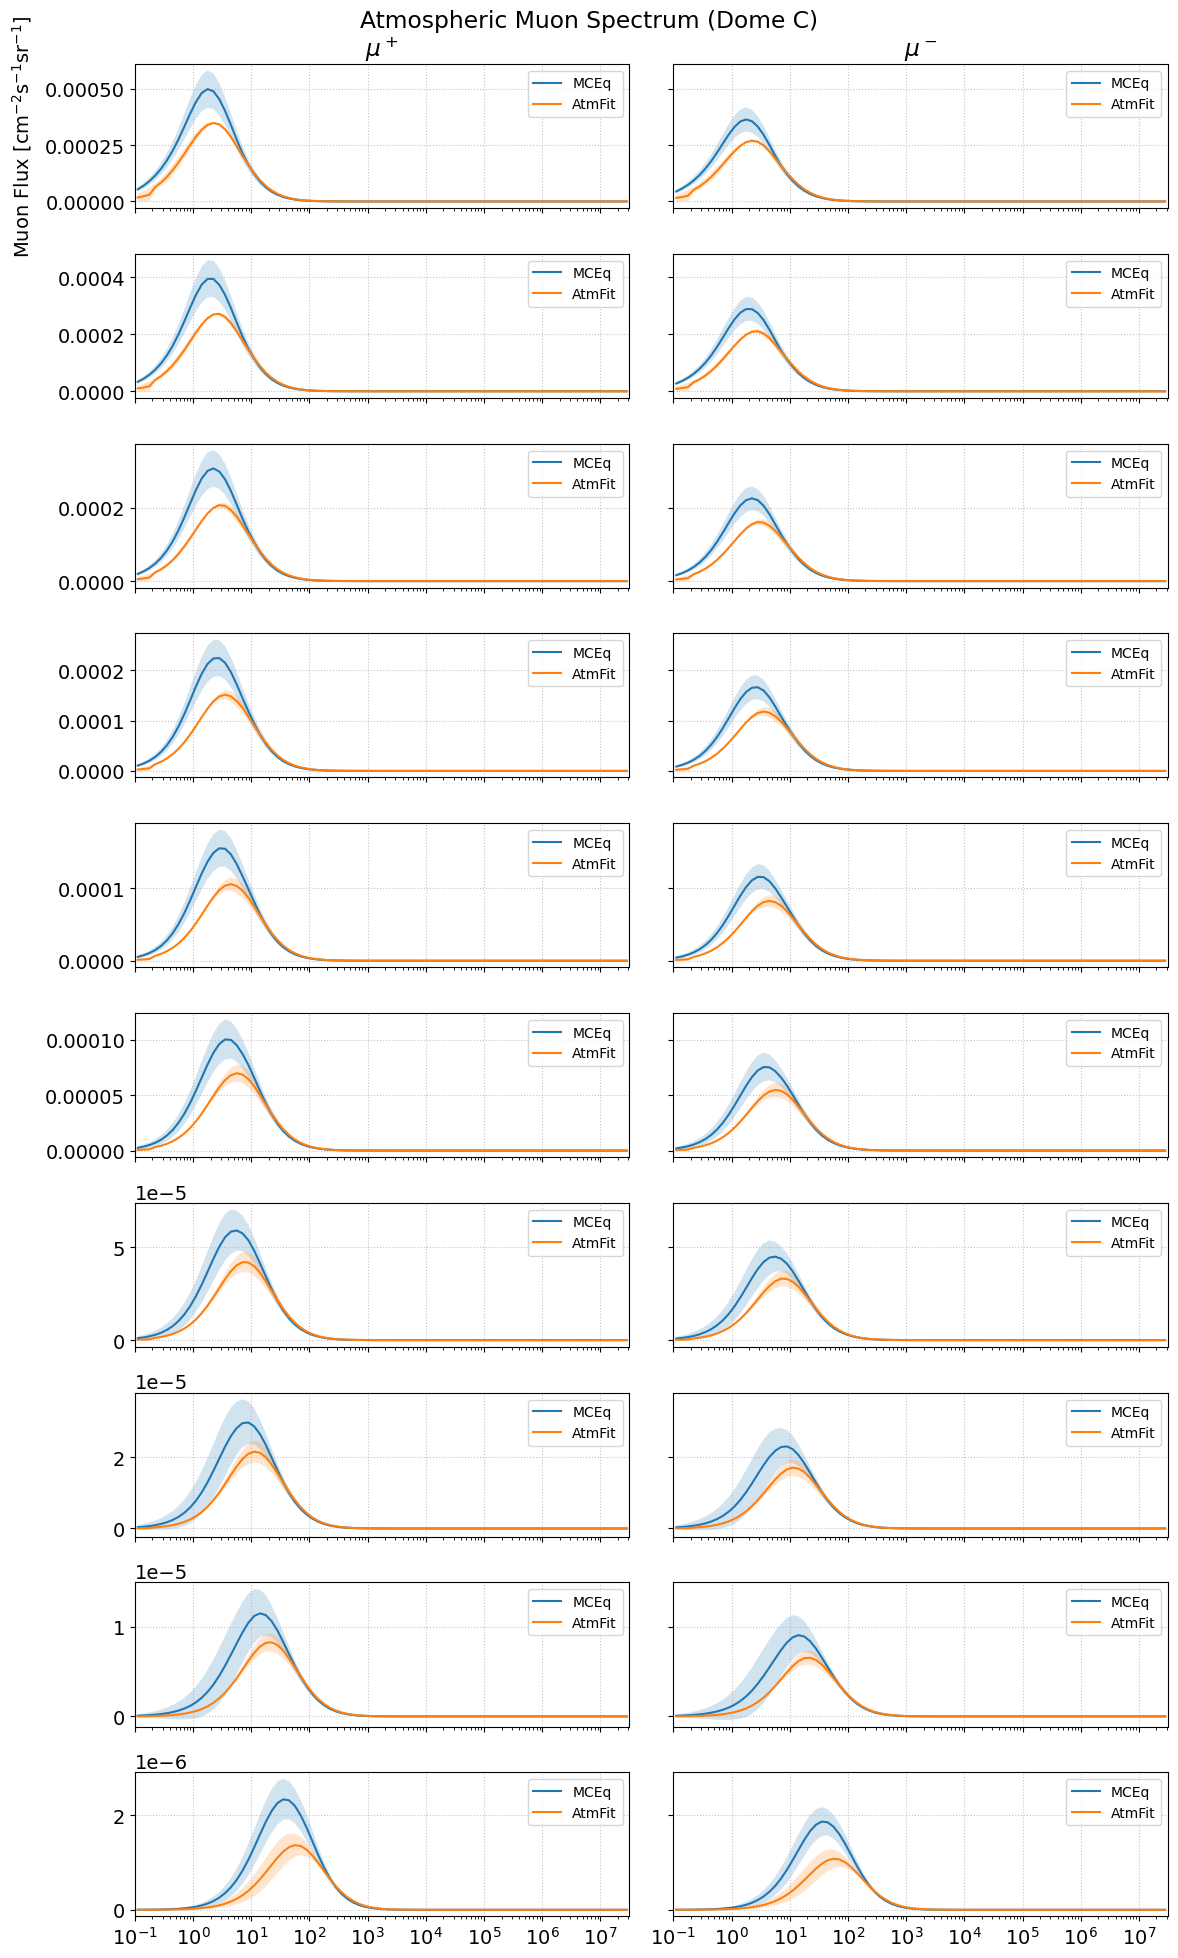

In [147]:
# Plot muon spectrum @ angle + deviations
Prop = Prop_DC

fig, axes = plt.subplots(10,2, figsize=(12,20), tight_layout=True, sharex = True, sharey='row')

E = Prop.E_mu

Atm_cut = Atm_avg[:,0]*Prop.dE_mu.reshape((1,1,1,-1))
Atm_std = np.array([std(A*Prop.dE_mu.reshape((*([1]*len(ax)),1,1,1,-1)), w.reshape((*w.shape,1,1,1,1)), ax) for A,w,ax in zip([Atm_MCEq, Atm_AtmFit], [w_MCEq_atm, w_AtmFit_atm], [(0,1,2),(0,)])])[:,0] # standard deviations of total muon flux
#H_E = F.Heisinger(h)[0]

th_i = np.arange(10)

for j in range(len(th_i)):
    for i in range(2): # pos, neg
        for A,dA,l in zip(Atm_cut[:,th_i[j],i], Atm_std[:,th_i[j],i], production_models[:2]):
            axes[j,i].fill_between(E, A-dA, A+dA, alpha=0.2)
            axes[j,i].plot(E, A, label=l)
        axes[j,i].legend(fontsize=10)
axes[0,0].set(
    title=r'$\mu^+$',
    xlim=(Prop.E_mu_bins[0],Prop.E_mu_bins[-1]),
    xscale='log',
    #xlabel='Energy [GeV]',
    ylabel=r'Muon Flux [cm$^{-2}$s$^{-1}$sr$^{-1}$]',
    #yscale='log',
)
axes[0,1].set(
    title=r'$\mu^-$',
)
fig.suptitle('Atmospheric Muon Spectrum (Dome C)')
plt.show()

## f-factor Priors

In [32]:
sigma_E = 4.5e-28
dsigma_E = 2.5e-28

f_tot = 0.1828 * 0.137 #4.4e-3 #<- fake; where did I get this value?
df_tot = 0.1828 * 0.011 #2.6e-3 #<- nope!

Omega_CO = 0.3

f_fast_H = Omega_CO
df_fast_H = Omega_CO * dsigma_E/sigma_E

f_neg_H = Omega_CO
df_neg_H = Omega_CO * df_tot/f_tot

f_avg = np.array([f_fast_H, f_neg_H])
f_cov = np.diag(np.array([df_fast_H, df_neg_H])**2)
f_cov_inv = np.diag(np.array([df_fast_H, df_neg_H])**-2)
f_std = np.diag([df_fast_H, df_neg_H])

In [33]:
def u_to_f(u):
    return f_avg + f_std @ scipy.stats.norm.ppf(u)

In [34]:
df = 0.01
f_fast_bins = np.arange(0.,1.+df/2,df)
#f_fast_bins = np.array([0.14,0.16])
f_fast = (f_fast_bins[:-1]+f_fast_bins[1:])/2
df_fast = np.diff(f_fast_bins)
f_neg_bins = np.arange(0.,1.+df/2,df)
#f_neg_bins = np.array([0.14,0.16])
f_neg = (f_neg_bins[:-1]+f_neg_bins[1:])/2
df_neg = np.diff(f_neg_bins)

f = np.array(np.meshgrid(f_fast,f_neg, indexing='ij')).reshape((2,-1)).T
df2 = (df_fast.reshape((-1,1))*df_neg.reshape((1,-1))).reshape((-1))
#axis0 - f-factors
#axis1 - Production Mode
f.shape

(10000, 2)

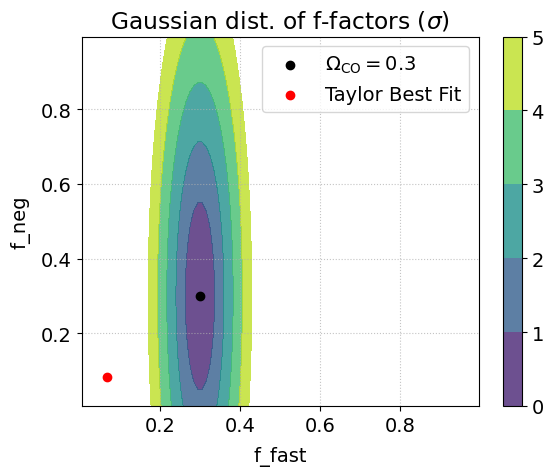

In [35]:
chi2_H = ((f_fast-f_fast_H)/df_fast_H).reshape((-1,1))**2+((f_neg-f_neg_H)/df_neg_H).reshape((1,-1))**2
sig_H = stats.norm.isf(stats.chi2.sf(chi2_H,2)/2)
L_H = np.exp(-chi2_H/2)/np.sqrt((2*np.pi)**2*df_fast_H*df_neg_H)*df_fast.reshape((-1,1))*df_neg.reshape((-1,1))
cont = plt.contourf(f_fast,f_neg, sig_H, alpha=0.8, levels=np.arange(6))
#cont = plt.contourf(f_fast,f_neg, np.log(L_H), alpha=0.8)
plt.colorbar(cont)
plt.scatter(0.3,0.3,c='k', label=r'$\Omega_{\text{CO}} = 0.3$')
plt.scatter(0.067,0.084, c='r', label='Taylor Best Fit')
plt.xlabel('f_fast')
plt.ylabel('f_neg')
plt.legend()
plt.title(r'Gaussian dist. of f-factors ($\sigma$)')
plt.show()

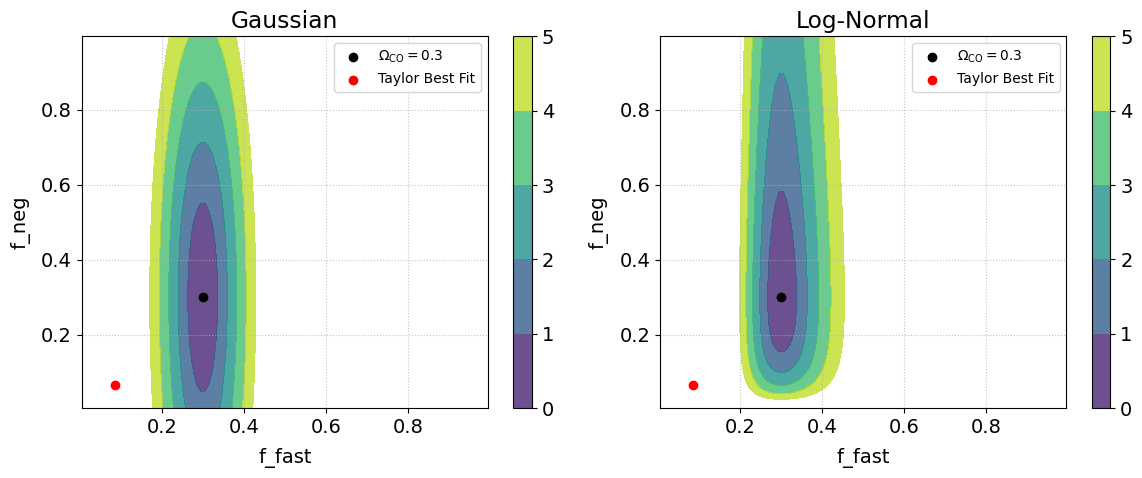

In [118]:
fig, axes = plt.subplots(1,2, figsize=(12,5), tight_layout=True)

f_TG = np.array([0.085, 0.068])

chi2_H = ((f_fast-f_fast_H)/df_fast_H).reshape((-1,1))**2+((f_neg-f_neg_H)/df_neg_H).reshape((1,-1))**2
sig_H = stats.norm.isf(stats.chi2.sf(chi2_H,2)/2)
L_H = np.exp(-chi2_H/2)/np.sqrt((2*np.pi)**2*df_fast_H*df_neg_H)*df_fast.reshape((-1,1))*df_neg.reshape((-1,1))
cont = axes[0].contourf(f_fast,f_neg, sig_H, alpha=0.8, levels=np.arange(6))
#cont = plt.contourf(f_fast,f_neg, np.log(L_H), alpha=0.8)
plt.colorbar(cont)
axes[0].scatter(0.3,0.3,c='k', label=r'$\Omega_{\text{CO}} = 0.3$')
axes[0].scatter(*f_TG, c='r', label='Taylor Best Fit')
axes[0].set(
    xlabel='f_fast',
    ylabel='f_neg',
    title='Gaussian',
)
axes[0].legend(fontsize=10)

chi2_H = ((np.log(f_fast)-np.log(f_fast_H))/np.log(1+df_fast_H/f_fast_H)).reshape((-1,1))**2+((np.log(f_neg)-np.log(f_neg_H))/np.log(1+df_neg_H/f_neg_H)).reshape((1,-1))**2
sig_H = stats.norm.isf(stats.chi2.sf(chi2_H,2)/2)
L_H = np.exp(-chi2_H/2)/np.sqrt((2*np.pi)**2*np.log(1+df_fast_H/f_fast_H)*np.log(1+df_neg_H/f_neg_H))*(df_fast/f_fast).reshape((-1,1))*(df_neg/f_neg).reshape((-1,1))
cont = axes[1].contourf(f_fast,f_neg, sig_H, alpha=0.8, levels=np.arange(6))
#cont = plt.contourf(f_fast,f_neg, np.log(L_H), alpha=0.8)
plt.colorbar(cont)
axes[1].scatter(0.3,0.3,c='k', label=r'$\Omega_{\text{CO}} = 0.3$')
axes[1].scatter(*f_TG, c='r', label='Taylor Best Fit')
axes[1].set(
    xlabel='f_fast',
    ylabel='f_neg',
    title='Log-Normal',
)
axes[1].legend(fontsize=10)
#plt.suptitle(r'Potential f-factor Distributions ($\sigma$) of Heisinger+ Uncertainties')
plt.show()

## CR Flux History Priors

In [37]:
def u_to_phi(u):
    # transform uniformly distributed Unit Cube to prior distribution on phi
    return 2*u

In [91]:
phi0 = np.ones((1,len(t)))

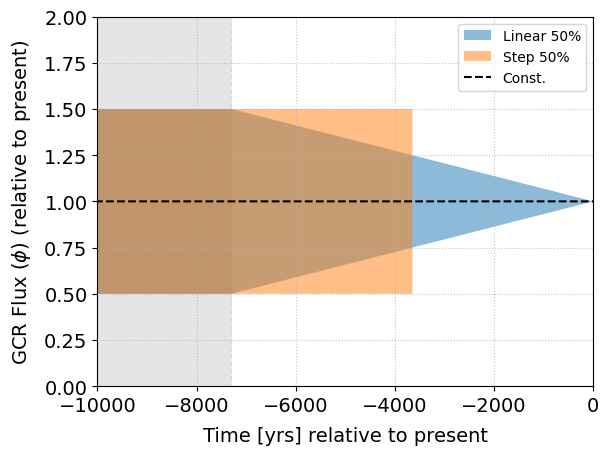

In [95]:
#plt.plot(t, phi.T, c='grey')
plt.axvspan(t_bins[0], t_bins_DC[0], color='grey', ls='--', alpha=0.2)
plt.fill_between(t, 1+t_scale.clip(min=-1)*0.5, 1-t_scale.clip(min=-1)*0.5, alpha=0.5, label='Linear 50%')
plt.fill_between(t, 1-0.5*(t_scale<-0.5), 1+0.5*(t_scale<-0.5), alpha=0.5, label='Step 50%')
plt.plot(t, 1+t_scale*0, c='k', ls='--', label='Const.')
plt.xlim(-10000,t_bins_DC[-1])
plt.ylim(0,2)
plt.xlabel('Time [yrs] relative to present')
plt.ylabel(r'GCR Flux ($\phi$) (relative to present)')
plt.legend(fontsize=10)
#plt.title('GCR Flux Models vs Time')
plt.show()

## Accumulation Model

In [40]:
def get_H_mat(h, x):
    h_slope = ((x-h[:,:-1])/np.diff(h,axis=1)).clip(0,1) # slope from 0 to 1 as x passes from lower to upper bound
    return np.concatenate([1*(x>=h[:,0])-h_slope[:,0], -np.diff(h_slope, axis=1), h_slope[:,-1]-1*(x>h[:,-1])], axis=1)

In [41]:
h_DC = Prop_DC.h.reshape((1,-1,1,1)) # production depths
x_DC = Prop_DC.h_prime(Prop_DC.h_accum.reshape((1,1,-1,1)), t.reshape((1,1,1,-1))) # accumulation depths

H_DC = get_H_mat(h_DC, x_DC)
#axis0 - Accumulation Model
#axis1 - Production Depth
#axis2 - Accumulation Depth
#axis3 - Time
H_DC.shape

(1, 255, 183, 7724)

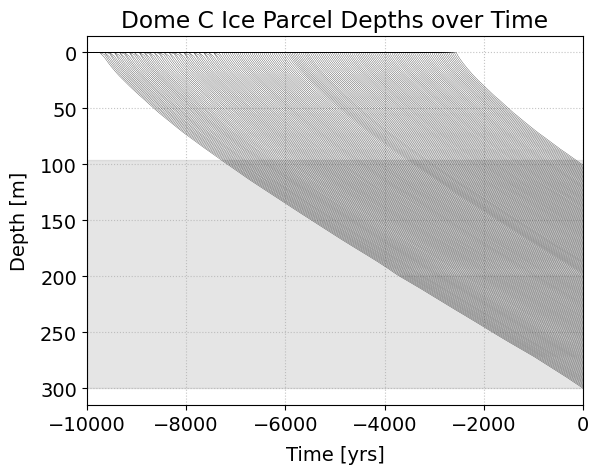

In [42]:
plt.axhspan(Prop_DC.z_close, Prop_DC.z_samp_bins[-1,-1], color='grey', alpha=0.2)
plt.plot(t, Prop_DC.h_to_z(x_DC[0,0].T), c='k', lw=0.2)
plt.xlabel('Time [yrs]')
plt.ylabel('Depth [m]')
plt.xlim(-10000,0)
plt.gca().invert_yaxis()
plt.title('Dome C Ice Parcel Depths over Time')
plt.show()

In [43]:
S_mat_DC = (Prop_DC.h_samp_bins[1].reshape((1,-1))-Prop_DC.h_accum_bins[:-1].reshape((-1,1))).clip(0,Prop_DC.dh_accum.reshape((-1,1))) - (Prop_DC.h_samp_bins[0].reshape((1,-1))-Prop_DC.h_accum_bins[:-1].reshape((-1,1))).clip(0,Prop_DC.dh_accum.reshape((-1,1)))
S_mat_DC /= np.sum(S_mat_DC, axis=0, keepdims=True)
#axis0 - Accumulation Depth
#axis1 - Sample Depth
S_mat_DC.shape

(183, 10)

In [44]:
A_DC = np.einsum('ilak,aj,k->ijkl', H_DC[:,Prop_DC.z>Prop_DC.z_close], S_mat_DC, np.exp(Prop_DC.lambd*t)*dt, optimize=True)
#axis0 - Accumulation Model
#axis1 - Sample Depth
#axis2 - Time
#axis3 - Production Depth
A_DC.shape

(1, 10, 7724, 194)

In [45]:
A0_DC = phi0 @ A_DC

In [46]:
flow='best'
#flow = 'trim'
if flow=='best' or flow=='sample':
    flowpath = loadmat('matlab/MC_14CO_mod/flowpath_sample.mat')
    h_age = flowpath['h_age']
elif flow=='all':
    flowpath = loadmat('matlab/MC_14CO_mod/flowpath_all.mat')
    h_age = flowpath['h_age']
else:
    flowpath = loadmat('matlab/MC_14CO_mod/flowpath_trim.mat')
    h_age = np.swapaxes(flowpath['h_trim'], 1,2)
# h_age : ice parcel depth as a function of age [m]
#axis0 - sample depth
#axis1 - flowpath
#axis2 - ice parcel age

age = flowpath['age'][0]
# age : ice parcel ages [years]
#axis0 - ice parcel age
h_age.shape

(8, 1, 861)

In [47]:
h_TG = Prop_TG.h.reshape((1,-1,1,1)) # production depths
x_TG = np.expand_dims(interp1d(-age, -h_age.swapaxes(0,1), bounds_error=False, fill_value=-h_age[:,:,-1].T)(t), axis=1)
# accumulation depths over time, based on end depth

A0_TG = np.array([phi0 @ (get_H_mat(h_TG, x.reshape((1,*x.shape)))*np.exp(Prop_TG.lambd*t)*dt).swapaxes(-2,-1) for x in tqdm(x_TG)])[:,0].swapaxes(-3,-1)
#axis0 - Flowpath
#axis1 - Sample Depth (TG)
#axis2 - CR History Model
#axis3 - Production Depth (TG)
A0_TG.shape

100%|█████████████████████████████████████████████████████████████████████████████████████| 1/1 [00:00<00:00,  1.66it/s]


(1, 8, 1, 999)

In [48]:
h_TG = Prop_TG.h.reshape((1,-1,1,1)) # production depths
x_TG = np.expand_dims(interp1d(-age, -h_age.swapaxes(0,1), bounds_error=False, fill_value=-h_age[:,:,-1].T)(t), axis=1)
# accumulation depths over time, based on end depth

H_TG = get_H_mat(h_TG, x_TG)
#axis0 - Flowpath
#axis1 - Production Depth (TG)
#axis2 - Sample Depth (TG)
#axis3 - Time
H_TG.shape

(1, 999, 8, 7724)

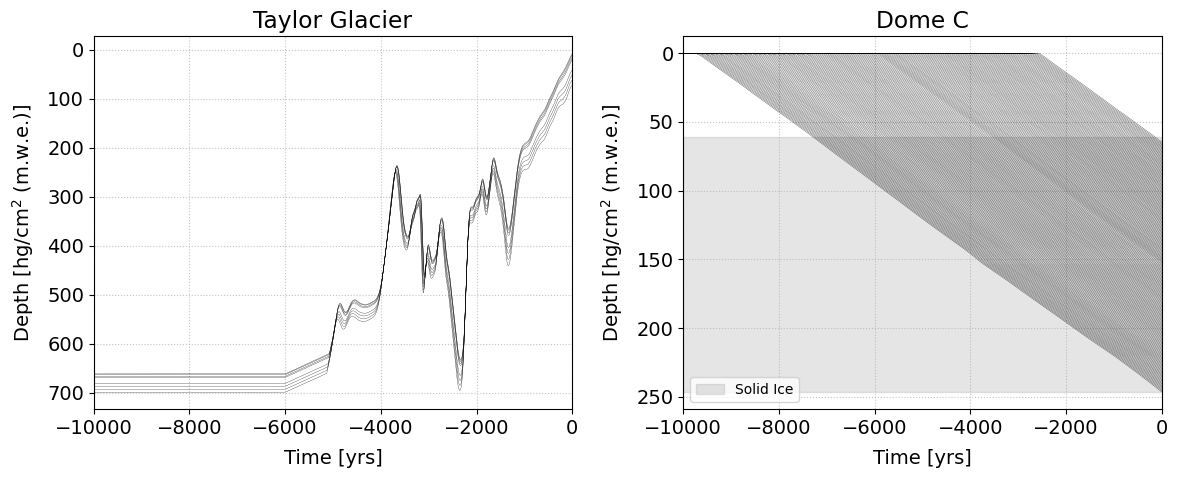

In [49]:
fig, axes = plt.subplots(1,2, figsize=(12,5), tight_layout=True, sharex = False, sharey=False)

axes[0].plot(t, x_TG[0,0].T, c='k', lw=0.2)
axes[0].set(
    xlabel='Time [yrs]',
    xlim=(-10000,0),
    ylabel=r'Depth [hg/cm$^2$ (m.w.e.)]',
    title='Taylor Glacier',
)
axes[0].yaxis.set_inverted(True)
#axes[0].legend(fontsize=10)

axes[1].axhspan(Prop_DC.z_to_h(Prop_DC.z_close), Prop_DC.h_samp_bins[-1,-1], color='grey', alpha=0.2, label='Solid Ice')
axes[1].plot(t, x_DC[0,0].T, c='k', lw=0.2)
axes[1].set(
    xlabel='Time [yrs]',
    xlim=(-10000,0),
    ylabel=r'Depth [hg/cm$^2$ (m.w.e.)]',
    title='Dome C',
)
axes[1].legend(fontsize=10)
axes[1].yaxis.set_inverted(True)

#plt.suptitle('Ice Parcel Accumulation Depths over Time')
plt.show()

In [50]:
A_TG = np.einsum('iljk,k->ijkl', H_TG, np.exp(Prop_TG.lambd*t)*dt, optimize=True)
#axis0 - Flowpath
#axis1 - Sample Depth (TG)
#axis2 - Time
#axis3 - Production Depth (TG)
A_TG.shape

(1, 8, 7724, 999)

In [51]:
A = np.zeros((A_TG.shape[0], A_DC.shape[1]+A_TG.shape[1], A_DC.shape[2], A_DC.shape[3]+A_TG.shape[3]))
A[:,:A_DC.shape[1],:,:A_DC.shape[3]] = A_DC
A[:,A_DC.shape[1]:,:,A_DC.shape[3]:] = A_TG
#axis0 - Accumulation Model
#axis1 - Sample Depth
#axis2 - Time
#axis3 - Production Depth
A.shape

(1, 18, 7724, 1193)

In [52]:
A0_TG.shape

(1, 8, 1, 999)

In [53]:
A0 = np.zeros((A0_TG.shape[0], A0_DC.shape[1]+A0_TG.shape[1], 1, A0_DC.shape[3]+A0_TG.shape[3]))
A0[:,:A_DC.shape[1],:,:A_DC.shape[3]] = A0_DC
A0[:,A_DC.shape[1]:,:,A_DC.shape[3]:] = A0_TG
A0.shape
#axis0 - Accumulation Model
#axis1 - Sample Depth
#axis3 - Production Depth

(1, 18, 1, 1193)

In [109]:
# Sensitivity = Contribution to observed 14CO per gram of sample per year
# S = APf

prod_cut = np.concatenate((Prop_DC.z>Prop_DC.z_close, Prop_TG.z>Prop_TG.z_close))
z_samp = np.concatenate((Prop_DC.z_samp, z_samp_TG))

f_TG = np.array([0.085, 0.068])

S = np.einsum('ija,a->ij', A[0], f_TG @ P_Heisinger[-1][:,prod_cut], optimize=True)/dt

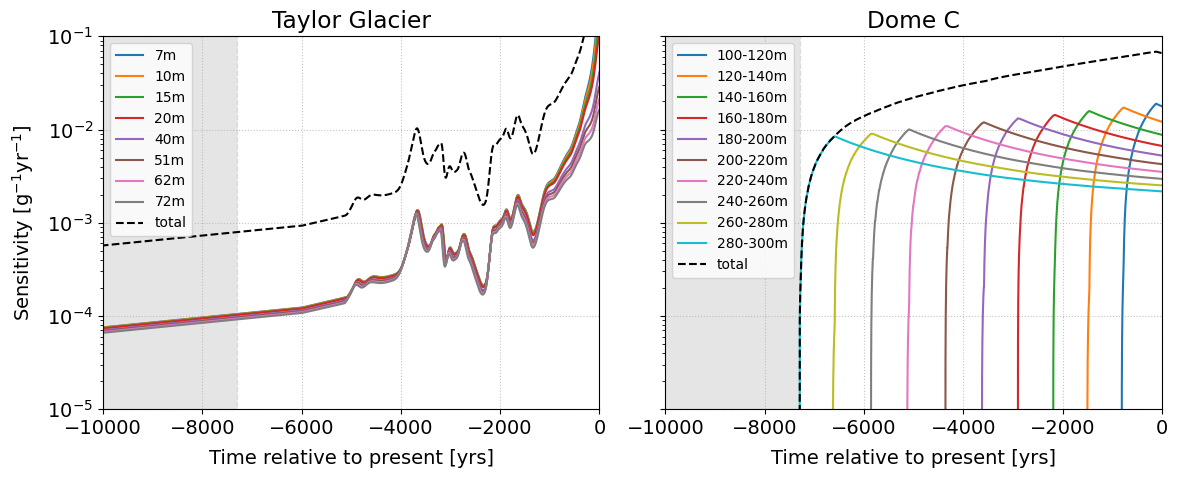

In [112]:
fig, axes = plt.subplots(1,2, figsize=(12,5), tight_layout=True, sharex = False, sharey=True)

x = np.arange(len(t))-len(t)+0.5

axes[0].axvspan(t_bins[0], t_bins_DC[0], color='grey', ls='--', alpha=0.2)
for i in range(10,len(z_samp)):
    axes[0].plot(t,S[i], label='{:.0f}m'.format(z_samp_TG[i-10]))
axes[0].plot(t,np.sum(S[10:],axis=0), c='k', ls='--', label='total')
axes[0].set(
    xlim = (-1e4,0),
    xlabel='Time relative to present [yrs]',
    #yscale='log',
    ylabel=r'Sensitivity [g$^{-1}$yr$^{-1}$]',
    title='Taylor Glacier',
)
axes[0].legend(loc='upper left', fontsize=10)

axes[1].axvspan(t_bins[0], t_bins_DC[0], color='grey', ls='--', alpha=0.2)
for i in range(10):
    axes[1].plot(t,S[i], label='{:.0f}-{:.0f}m'.format(*Prop_DC.z_samp_bins[:,i]))
axes[1].plot(t,np.sum(S[:10],axis=0), c='k', ls='--', label='total')
axes[1].set(
    xlim = (-1e4,0),
    xlabel='Time relative to present [yrs]',
    ylim = (1e-5,1e-1),
    yscale='log',
    title='Dome C',
)
axes[1].legend(loc='upper left', fontsize=10)
plt.show()

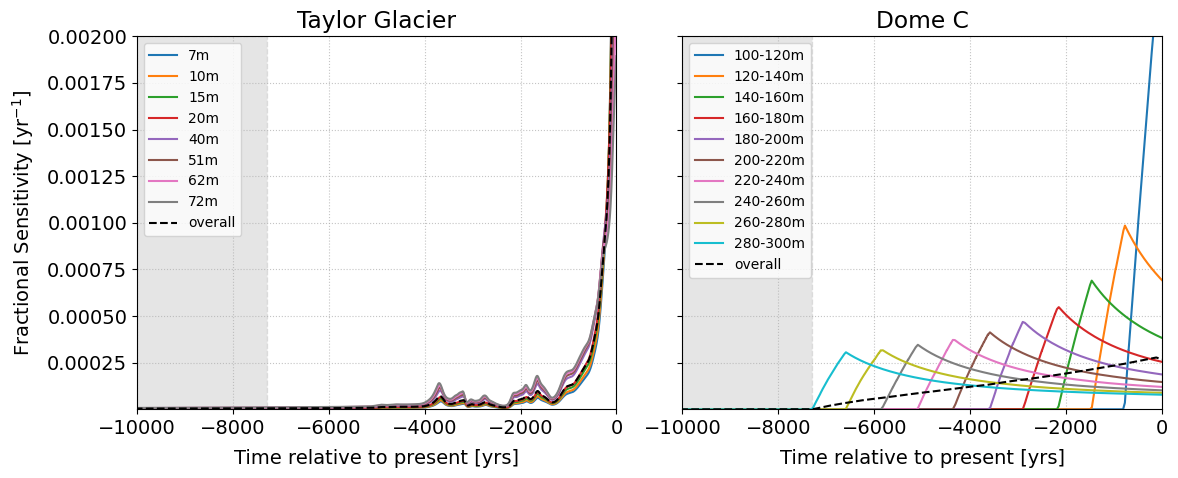

In [111]:
fig, axes = plt.subplots(1,2, figsize=(12,5), tight_layout=True, sharex = False, sharey=True)

x = np.arange(len(t))-len(t)+0.5

axes[0].axvspan(t_bins[0], t_bins_DC[0], color='grey', ls='--', alpha=0.2)
for i in range(10,len(z_samp)):
    axes[0].plot(t,S[i]/np.sum(S[i]*dt), label='{:.0f}m'.format(z_samp_TG[i-10]))
axes[0].plot(t,np.sum(S[10:],axis=0)/np.sum(S[10:]*dt), c='k', ls='--', label='overall')
axes[0].set(
    xlim = (-1e4,0),
    xlabel='Time relative to present [yrs]',
    #yscale='log',
    ylabel=r'Fractional Sensitivity [yr$^{-1}$]',
    title='Taylor Glacier',
)
axes[0].legend(loc='upper left', fontsize=10)

axes[1].axvspan(t_bins[0], t_bins_DC[0], color='grey', ls='--', alpha=0.2)
for i in range(10):
    axes[1].plot(t,S[i]/np.sum(S[i]*dt), label='{:.0f}-{:.0f}m'.format(*Prop_DC.z_samp_bins[:,i]))
axes[1].plot(t,np.sum(S[:10],axis=0)/np.sum(S[:10]*dt), c='k', ls='--', label='overall')
axes[1].set(
    xlim = (-1e4,0),
    xlabel='Time relative to present [yrs]',
    ylim = (1e-6,2e-3),
    #yscale='log',
    title='Dome C',
)
axes[1].legend(loc='upper left', fontsize=10)
plt.show()

## Combined Null Model Prior

In [ ]:
def const_prior(f, low=0., high=1.):
    return np.prod((f>=low)*(f<=high)/(high-low))

def inv_prior(f, low=0.01, high=1.):
    return np.prod((1/f)*(f>=low)*(f<=high)/np.log(high/low), axis=-1)

def gauss_prior(f, mean=f_avg, inv_cov=f_cov_inv):
    return np.exp(-np.sum((f-mean)@inv_cov*(f-mean),axis=-1)/2)*np.sqrt(np.linalg.det(inv_cov/2/np.pi))

#Production Model Priors
p_models = np.ones(3)
#p_P = np.ones(P_avg.shape[0])
p_P = (p_models.reshape((-1,1)) * w_alpha.reshape((1,-1))).reshape((-1))
p_P /= np.sum(p_P)
logp_P = np.log(p_P)
#logp_P.shape

#logp_f = logpf(f) * df?? # prior should be inverse to f
#p_f = inv_prior(f)*df2
p_f = gauss_prior(f)*df2
#p_f /= np.sum(p_f)
logp_f = np.log(p_f)
#logp_f.shape

#logp_phi = logpphi(phi) * dphi?? # prior should be inverse to how wonky the flux looks
p_phi0 = np.ones(len(phi0))
p_phi0 /= np.sum(p_phi0)
logp_phi0 = np.log(p_phi0)
#logp_phi.shape

p_A = np.ones(A0.shape[0])
p_A /= np.sum(p_A)
logp_A = np.log(p_A)
#logp_Z.shape

logp0 = (logp_P.reshape((-1,1,1,1))+logp_f.reshape((1,-1,1,1))+logp_phi0.reshape((1,1,-1,1))+logp_A.reshape((1,1,1,-1)))
logp0.shape

## Predicted 14CO & Uncertainty

In [ ]:
prod_cut = np.concatenate((Prop_DC.z>Prop_DC.z_close, Prop_TG.z>Prop_TG.z_close))
z_samp = np.concatenate((Prop_DC.z_samp, z_samp_TG))

In [ ]:
C_pred = np.einsum('lmka,ija->ijklm', A0, f @ P_avg[:,:,prod_cut], optimize=True)
#axis0 - Production ModelSet
#axis1 - f-factors
#axis2 - CR History
#axis3 - Accumulation Model
#axis4 - Sample Depth
C_pred.shape

In [ ]:
C_pred_cov = np.einsum('lmkc,lnkd,ja,jb,iabcd->ijklmn',A0, A0, f, f, P_cov[:,:,:,prod_cut][:,:,:,:,prod_cut], optimize=True)
#axis0 - Production ModelSet
#axis1 - f-factors
#axis2 - CR History
#axis3 - Accumulation Model
#axis4 - Sample Depth
#axis5 - Sample Depth
C_pred_cov.shape

## Simulated 14CO Samples

In [ ]:
rel_err = 0.02

In [ ]:
s_P = np.cumsum(p_P)
s_A = np.cumsum(p_A)

def ptform_sample(u):
    # Generates a simulated 14CO sample, with parameters transformed from a draw on the Unit Cube (N-dimensional)
    
    # Unit Cube Parameter Dimension Allocation
    # 0 : Production model (P, Sigma_P)
    # 1 : Accumulation model (A)
    # 2-3 : f-factors (f)
    # +len(t) : CR Flux History (phi) (optional)
    # +len(z_samp) : Production model uncertainties (Delta_C_true) (optional)
    # +len(z_samp) : Experimental error (Delta_C_exp) (optional)
    
    i = np.digitize(u[0], s_P)
    j = np.digitize(u[1], s_A)
    
    f = u_to_f(u[2:4])
    
    #phi = u_to_phi(u[4:4+len(t)])
    phi = np.ones(len(t))
    
    C_pred = A0[j,:,0] @ (f @ P_avg[i][:,prod_cut])
    C_pred_cov = np.einsum('ic,jd,a,b,abcd->ij', A0[j,:,0], A0[j,:,0], f, f, P_cov[i][:,:,prod_cut][:,:,:,prod_cut], optimize=True)
    #C_pred_std = np.einsum('ia,b,baj->ij', phi@A_samp[j], f, P_std[i,:,prod_cut][:,:,prod_cut], optimize=True)
    #C_pred_std = sym_sqrt(C_pred_cov)
    C_pred_std = np.real(scipy.linalg.sqrtm(C_pred_cov))
    
    #Delta_C_true = stats.multivariate_normal.rvs(cov=C_pred_cov, random_state=u[4])
    
    Delta_C_true = C_pred_std @ scipy.stats.norm.ppf(u[4:4+len(z_samp)])
    
    C_true = C_pred + Delta_C_true
    dC_true = rel_err * C_true
    
    Delta_C_samp = dC_true * scipy.stats.norm.ppf(u[4+len(z_samp):4+2*len(z_samp)])
    
    C_samp = C_true + Delta_C_samp
    C_samp_cov = np.diag((rel_err * C_samp)**2)
    
    return C_samp, C_samp_cov

In [ ]:
def quick_sample(N):
    i = np.random.choice(np.arange(len(p_P)), size=N, p=p_P)
    j = np.random.choice(np.arange(len(p_A)), size=N, p=p_A)
    
    f = np.random.multivariate_normal(f_avg, f_cov, size=N)
    
    phi0 = np.ones(len(t))
    
    #C_pred = (phi @ A[j]) @ (f @ P_avg[i][:,prod_cut])
    C_pred = np.einsum('ija,iba,ib->ij', A0[j,:,0], P_avg[i][:,:,prod_cut], f, optimize=True)
    C_pred_cov = np.einsum('ija,ikb,ic,id,icdab->ijk',A0[j,:,0], A0[j,:,0], f, f, P_cov[i][:,:,:,prod_cut][:,:,:,:,prod_cut], optimize=True)
    
    C_true = np.array([np.random.multivariate_normal(c, cov) for c,cov in zip(C_pred, C_pred_cov)])
    
    s = np.random.normal(1., rel_err, C_true.shape)
    
    C_samp = C_true * s
    
    #C_samp_cov = np.zeros((*C_samp.shape,len(z_samp)))
    #C_samp_cov[:,np.arange(len(z_samp)),np.arange(len(z_samp))] = (rel_err * C_samp)**2

    return C_samp#, C_samp_cov

In [ ]:
u = np.random.random(4+len(z_samp)*2)
C_samp, C_samp_cov = ptform_sample(u)

## log Likelihood

In [ ]:
def loglike(dC, C_cov):
    
    return -np.einsum('...a,...ab,...b->...', dC, np.linalg.inv(C_cov), dC, optimize=True)/2 - np.log(np.linalg.det(2*np.pi*C_cov))/2

In [ ]:
def logev_null(C_exp):
    C_exp_cov = np.diag((rel_err * C_exp)**2)
    
    dC = C_exp - C_pred
    C_cov = C_exp_cov + C_pred_cov
    
    logLp = logp0+loglike(dC, C_cov)
    norm = np.max(logLp)
    
    return np.log(np.sum(np.exp(logLp-norm)))+norm

In [ ]:
def logev_null_bulk(C_exp):
    C_exp_cov = np.zeros((*C_exp.shape,len(z_samp)))
    C_exp_cov[:,np.arange(len(z_samp)),np.arange(len(z_samp))] = (rel_err * C_exp)**2
    
    dC = C_exp.reshape((-1,1,1,1,1,len(z_samp))) - C_pred.reshape((1,*C_pred.shape))
    C_cov = C_exp_cov.reshape((-1,1,1,1,1,len(z_samp),len(z_samp))) + C_pred_cov.reshape((1,*C_pred_cov.shape))
    
    logLp = logp0.reshape((1,*logp0.shape))+loglike(dC, C_cov)
    norm = np.max(logLp, axis=(1,2,3,4))
    
    return np.log(np.sum(np.exp(logLp-norm), axis=(1,2,3,4)))+norm

In [ ]:
def logpost_null(C_exp, C_exp_cov):
    #C_exp_cov = np.diag((rel_err * C_exp)**2)
    
    dC = C_exp - C_pred
    C_cov = C_exp_cov + C_pred_cov
    
    logLp = logp0+loglike(dC, C_cov)
    norm = np.max(logLp)
    
    logZ = np.log(np.sum(np.exp(logLp-norm)))+norm
    
    return logLp-logZ, logZ

In [ ]:
N=1000
M=1
Z_dist = np.reshape([[logev_null(c) for c in quick_sample(M)] for i in tqdm(range(N//M))], -1)

In [ ]:
plt.plot((np.arange(N)+0.5)/N, -np.sort(Z_dist))
plt.ylabel(r'Null Model Evidence ($\log Z$)')
plt.xlabel('p-value')
#plt.xscale('log')
for s in range(5):
    plt.axvline(scipy.stats.norm.sf(s+1)*2, c='grey', ls='--', alpha=0.5)